In [3]:
pip install pandas numpy lifetimes scikit-learn xgboost matplotlib seaborn

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 52.8/52.8 kB ? eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ---------------------------------------- 119.8/119.8 kB ? eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Statistical Models
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet, LinearRegression
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Data Loading And Cleaning 

In [6]:
pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   -------------- ------------------------- 92.2/250.9 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 3.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Load the dataset (both sheets)
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df1, df2], ignore_index=True)

print("Original shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 2. Drop rows with missing CustomerID
df.dropna(subset=['Customer ID'], inplace=True)

# 3. Remove cancelled transactions (InvoiceNo starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 4. Remove rows with negative or zero Quantity
df = df[df['Quantity'] > 0]

# 5. Remove rows with negative or zero UnitPrice
df = df[df['Price'] > 0]

# 6. Remove invalid StockCodes (non-product codes)
invalid_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']
df = df[~df['StockCode'].astype(str).isin(invalid_codes)]
# Also remove StockCodes that are purely alphabetical (not real products)
df = df[df['StockCode'].astype(str).str.match(r'^\d')]

# 7. Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)


Original shape: (1067371, 8)

Missing values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [3]:
df_clean = df.copy()

In [4]:
print("\nCleaned shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values after cleaning:\n", df.isnull().sum())


Cleaned shape: (776577, 8)

Data types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country                   str
dtype: object

Missing values after cleaning:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


### Feature Engineering


In [5]:
#Feature Engineering
# Ensure Year column exists
df['Year'] = df['InvoiceDate'].dt.year

In [6]:
# 1. Frequency: Number of unique invoices per customer per year
frequency = (
    df.groupby(['Customer ID', 'Year'])['Invoice']
    .nunique()
    .reset_index()
    .rename(columns={'Invoice': 'Frequency'})
)

# 2. Monetary Value: Total purchase amount per customer per year
df['TotalPrice'] = df['Quantity'] * df['Price']
monetary = (
    df.groupby(['Customer ID', 'Year'])['TotalPrice']
    .sum()
    .reset_index()
    .rename(columns={'TotalPrice': 'Monetary_Value'})
)

In [7]:
# 3. Best Selling Product (per customer per year)
#    Most purchased product by total quantity
best_product = (
    df.groupby(['Customer ID', 'Year', 'Description'])['Quantity']
    .sum()
    .reset_index()
)
best_product = (
    best_product.loc[best_product.groupby(['Customer ID', 'Year'])['Quantity'].idxmax()]
    .rename(columns={'Description': 'Best_Selling_Product', 'Quantity': 'Best_Product_Quantity'})
    [['Customer ID', 'Year', 'Best_Selling_Product']]
)


In [8]:
# 4. Market Group Classification
def classify_market_group(description):
    if pd.isna(description):
        return 'Seasonal & Gifts'

    desc = description.upper()

    # Home & Kitchen
    home_keywords = [
        'MUG', 'CUP', 'BOWL', 'PLATE', 'DISH', 'TRAY', 'JUG', 'JAR',
        'STORAGE', 'BOX', 'BASKET', 'TIN', 'RACK', 'HOOK', 'HANGER',
        'CANDLE', 'HOLDER', 'COASTER', 'CLOTH', 'TOWEL', 'KITCHEN',
        'BOTTLE', 'FLASK', 'TEAPOT', 'KETTLE', 'SPOON', 'FORK',
        'KNIFE', 'CHOPPING', 'APRON', 'OVEN', 'CRATE', 'CABINET',
        'SHELF', 'CUSHION', 'PILLOW', 'BLANKET', 'THROW', 'RUG',
        'LAMP', 'LIGHT', 'CLOCK', 'MIRROR', 'PICTURE', 'FRAME',
        'CURTAIN', 'DOORMAT', 'MAT', 'SOAP', 'DISPENSER', 'BATHROOM'
    ]

    # Garden & Outdoor
    garden_keywords = [
        'GARDEN', 'PLANT', 'POT', 'PLANTER', 'BIRD', 'FEEDER',
        'WATERING', 'FENCE', 'SIGN', 'STAKE', 'OUTDOOR', 'FLOWER',
        'SEED', 'SOIL', 'TROWEL', 'SPADE', 'RAKE', 'BENCH',
        'LANTERN', 'WINDMILL', 'WEATHER', 'VANE', 'GNOME',
        'BUTTERFLY', 'BEE', 'INSECT', 'HEDGEHOG', 'FROG',
        'STONE', 'PEBBLE', 'BARK', 'LEAF', 'TREE', 'SHRUB'
    ]

    # Stationery & Office
    stationery_keywords = [
        'NOTEBOOK', 'NOTE BOOK', 'PEN', 'PENCIL', 'RULER', 'ERASER',
        'CARD', 'CARDS', 'NOTEPAD', 'PAD', 'MEMO', 'CALENDAR',
        'DIARY', 'JOURNAL', 'STICKER', 'TAPE', 'CLIP', 'STAPLE',
        'FOLDER', 'ENVELOPE', 'PAPER', 'LABEL', 'TAG', 'BOOK',
        'LETTER', 'POSTCARD', 'STAMP', 'INK', 'MARKER', 'HIGHLIGHTER',
        'SCISSOR', 'GLUE', 'STICKY', 'BINDER', 'FILE'
    ]

    # Toys & Games
    toys_keywords = [
        'TOY', 'DOLL', 'PUPPET', 'TEDDY', 'BEAR', 'ANIMAL',
        'PUZZLE', 'GAME', 'PLAY', 'BALL', 'BALLOON', 'KITE',
        'BLOCK', 'BRICK', 'TRAIN', 'CAR', 'PLANE', 'BOAT',
        'MAGIC', 'TRICK', 'DICE', 'CARD GAME', 'BOARD GAME',
        'SPINNER', 'MARBLE', 'JIGSAW', 'LEGO', 'ACTION',
        'FIGURINE', 'ROBOT', 'DRUM', 'WHISTLE', 'BUBBLE'
    ]

    # Seasonal & Gifts
    seasonal_keywords = [
        'CHRISTMAS', 'XMAS', 'SANTA', 'SNOWMAN', 'REINDEER',
        'VALENTINE', 'HEART', 'LOVE', 'EASTER', 'EGG', 'BUNNY',
        'HALLOWEEN', 'WITCH', 'PUMPKIN', 'GHOST', 'SKELETON',
        'BIRTHDAY', 'PARTY', 'CELEBRATION', 'WEDDING', 'GIFT',
        'PRESENT', 'WRAP', 'RIBBON', 'BOW', 'MOTHER', 'FATHER',
        'ANNIVERSARY', 'CONGRATULATION', 'THANK', 'BABY', 'SHOWER',
        'NEW YEAR', 'SPRING', 'SUMMER', 'AUTUMN', 'WINTER',
        'HOLIDAY', 'FESTIVE', 'DECORATION', 'ADVENT', 'WREATH'
    ]

    # Decorations & Craft
    decoration_keywords = [
        'BUNTING', 'BANNER', 'GARLAND', 'BUNTING', 'PENNANT',
        'CRAFT', 'DIY', 'PAINT', 'BRUSH', 'CANVAS', 'FABRIC',
        'FELT', 'WOOL', 'YARN', 'KNIT', 'SEW', 'NEEDLE',
        'BEAD', 'SEQUIN', 'BUTTON', 'RIBBON', 'LACE', 'TRIM',
        'MOSAIC', 'DECOUPAGE', 'STAMP', 'EMBOSS', 'WASHI',
        'ORNAMENT', 'FIGURINE', 'STATUE', 'SCULPTURE', 'MOBILE',
        'WINDCHIME', 'DREAMCATCHER', 'PHOTO', 'COLLAGE', 'PRINT',
        'WALL ART', 'POSTER', 'DECAL', 'STENCIL', 'MURAL'
    ]

    # Priority order: Seasonal first (very common in this dataset)
    if any(keyword in desc for keyword in seasonal_keywords):
        return 'Seasonal & Gifts'
    if any(keyword in desc for keyword in home_keywords):
        return 'Home & Kitchen'
    if any(keyword in desc for keyword in decoration_keywords):
        return 'Decorations & Craft'
    if any(keyword in desc for keyword in stationery_keywords):
        return 'Stationery & Office'
    if any(keyword in desc for keyword in garden_keywords):
        return 'Garden & Outdoor'
    if any(keyword in desc for keyword in toys_keywords):
        return 'Toys & Games'

    # Default fallback
    return 'Seasonal & Gifts'

best_product['Market_Group'] = best_product['Best_Selling_Product'].apply(classify_market_group)

In [9]:
#Province
province = (
    df.groupby(['Customer ID', 'Year'])['Country']
    .agg(lambda x: x.value_counts().index[0])  # most frequent country per customer per year
    .reset_index()
    .rename(columns={'Country': 'Province'})
)

In [10]:
customer_features = frequency.merge(monetary, on=['Customer ID', 'Year'], how='inner')
customer_features = customer_features.merge(best_product, on=['Customer ID', 'Year'], how='left')
customer_features = customer_features.merge(province, on=['Customer ID', 'Year'], how='left')

# ----------------------------
# 7. Reorder columns neatly
# ----------------------------
df1= customer_features[[
    'Customer ID', 'Frequency',
    'Monetary_Value','Year', 'Province', 'Best_Selling_Product', 'Market_Group'
]]

df1

,Customer ID,Frequency,Monetary_Value,Year,Province,Best_Selling_Product,Market_Group
0,12346,2,169.36,2010,United Kingdom,DOORMAT 3 SMILEY CATS,Home & Kitchen
1,12346,1,77183.60,2011,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,Home & Kitchen
2,12347,2,1323.32,2010,Iceland,MINI PAINT SET VINTAGE,Decorations & Craft
3,12347,6,3598.21,2011,Iceland,ICE CREAM SUNDAE LIP GLOSS,Seasonal & Gifts
4,12348,2,873.96,2010,Finland,60 TEATIME FAIRY CAKE CASES,Seasonal & Gifts
...,...,...,...,...,...,...,...
9365,18285,1,377.00,2010,United Kingdom,PAPER BUNTING WHITE LACE,Home & Kitchen
9366,18286,1,412.95,2009,United Kingdom,BLACK AND WHITE PAISLEY FLOWER MUG,Home & Kitchen
9367,18286,1,833.48,2010,United Kingdom,DINOSAUR KEYRINGS ASSORTED,Seasonal & Gifts
9368,18287,4,2295.71,2010,United Kingdom,SET/6 PURPLE BUTTERFLY T-LIGHTS,Home & Kitchen


In [11]:
df1.to_csv('final_dataset.csv', index=False)
print("\nSaved as 'final_dataset.csv'")


Saved as 'final_dataset.csv'


In [12]:
# ============================================================
# LOAD DATASET
# ============================================================
df = pd.read_csv('final_dataset.csv')
df['Customer ID'] = df['Customer ID'].astype(str)

print("Original shape:", df.shape)
print("Years present:", sorted(df['Year'].unique()))
print("Sample:\n", df.head())

# ============================================================
# STEP 1: Total Unique Customers per Year (firm-level)
# Used in denominator of Purchase Frequency & Retention Rate
# ============================================================
total_unique_customers_per_year = (
    df.groupby('Year')['Customer ID']
    .nunique()
    .reset_index()
    .rename(columns={'Customer ID': 'Total_Unique_Customers'})
)
print("\nTotal Unique Customers per Year:")
print(total_unique_customers_per_year)

# ============================================================
# STEP 2: Filter customers who made more than 1 purchase
#         across ALL years combined (total frequency > 1)
# ============================================================
total_frequency_per_customer = (
    df.groupby('Customer ID')['Frequency']
    .sum()
    .reset_index()
    .rename(columns={'Frequency': 'Total_Frequency_AllYears'})
)

# Keep customers with more than 1 purchase across all years
multi_purchase_customers = total_frequency_per_customer[
    total_frequency_per_customer['Total_Frequency_AllYears'] > 1
]['Customer ID']

df_filtered = df[df['Customer ID'].isin(multi_purchase_customers)].copy()
print(f"\nCustomers after filtering (>1 purchase across all years): {df_filtered['Customer ID'].nunique()}")
print(f"Rows after filtering: {df_filtered.shape[0]}")

# ============================================================
# STEP 3: Merge Total Unique Customers per Year into df_filtered
# ============================================================
df_filtered = df_filtered.merge(total_unique_customers_per_year, on='Year', how='left')

# ============================================================
# STEP 4: Firm-level yearly calculations
#
# Total_Sales (yearly)        = sum of Monetary_Value for all customers that year
# Total_OrderNumber (yearly)  = sum of Frequency for all customers that year
# ============================================================
firm_yearly = (
    df_filtered.groupby('Year')
    .agg(
        Total_Sales=('Monetary_Value', 'sum'),
        Total_OrderNumber=('Frequency', 'sum'),
        TotalOrderNumber_Greater_than_1=('Frequency', lambda x: (x > 1).sum())
    )
    .reset_index()
)

# Merge firm-level yearly stats back
df_filtered = df_filtered.merge(firm_yearly, on='Year', how='left')

print("\nFirm-level yearly stats:")
print(firm_yearly)

# ============================================================
# STEP 5: Individual-level calculations
#
# Average_Sales (per customer per year):
#   = Monetary_Value (individual) / Frequency (individual)
#
# Purchase_Frequency (per customer per year):
#   = Total_OrderNumber (firm yearly) / Total_Unique_Customers (firm yearly)
#   NOTE: numerator is firm-level, denominator is firm-level
#         but it reflects each customer's year context
# ============================================================
df_filtered['Average_Sales'] = (
    df_filtered['Monetary_Value'] / df_filtered['Frequency']
).round(4)

df_filtered['Purchase_Frequency'] = (
    df_filtered['Total_OrderNumber'] / df_filtered['Total_Unique_Customers']
).round(4)

# ============================================================
# STEP 6: Firm-level Churn Rate (per year)
#
# Retention_Rate = TotalOrderNumber_Greater_than_1 / Total_Unique_Customers
# Churn          = 1 - Retention_Rate
# ============================================================
df_filtered['Retention_Rate'] = (
    df_filtered['TotalOrderNumber_Greater_than_1'] / df_filtered['Total_Unique_Customers']
).round(4)

df_filtered['Churn'] = (1 - df_filtered['Retention_Rate']).round(4)

print("\nFirm-level Churn per Year:")
print(df_filtered[['Year', 'Retention_Rate', 'Churn']].drop_duplicates())

# ============================================================
# STEP 7: Profit Margin (firm-level assumption)
# ============================================================
PROFIT_MARGIN = 0.20

# ============================================================
# STEP 8: CLV Calculation per customer per year
#
# CLV = (Average_Sales × Purchase_Frequency / Churn) × Profit_Margin
# ============================================================
df_filtered['CLV'] = (
    (df_filtered['Average_Sales'] * df_filtered['Purchase_Frequency']) /
    df_filtered['Churn']
) * PROFIT_MARGIN

df_filtered['CLV'] = df_filtered['CLV'].round(4)

# ============================================================
# STEP 9: Final column order & cleanup
# ============================================================
final_clv = df_filtered[[
    'Customer ID',
    'Year',
    'Frequency',
    'Monetary_Value',
    'Province',
    'Best_Selling_Product',
    'Market_Group',
    'Average_Sales',
    'Purchase_Frequency',
    'Retention_Rate',
    'Churn',
    'CLV'
]].reset_index(drop=True)

# ============================================================
# STEP 10: Summary & Save
# ============================================================
print("\nFinal Dataset Shape:", final_clv.shape)
print("\nSample:\n", final_clv.head(10))
print("\nCLV Stats:\n", final_clv['CLV'].describe())
print("\nCLV per Year:\n", final_clv.groupby('Year')['CLV'].describe())

final_clv.to_csv('final_dataset_clv.csv', index=False)
print("\nSaved as 'final_dataset_clv.csv'")

Original shape: (9370, 7)
Years present: [np.int64(2009), np.int64(2010), np.int64(2011)]
Sample:
   Customer ID  Frequency  Monetary_Value  Year        Province  \
0       12346          2          169.36  2010  United Kingdom   
1       12346          1        77183.60  2011  United Kingdom   
2       12347          2         1323.32  2010         Iceland   
3       12347          6         3598.21  2011         Iceland   
4       12348          2          873.96  2010         Finland   

             Best_Selling_Product         Market_Group  
0           DOORMAT 3 SMILEY CATS       Home & Kitchen  
1  MEDIUM CERAMIC TOP STORAGE JAR       Home & Kitchen  
2         MINI PAINT SET VINTAGE   Decorations & Craft  
3      ICE CREAM SUNDAE LIP GLOSS     Seasonal & Gifts  
4     60 TEATIME FAIRY CAKE CASES     Seasonal & Gifts  

Total Unique Customers per Year:
   Year  Total_Unique_Customers
0  2009                     951
1  2010                    4205
2  2011                    4214


In [13]:
final_clv

,Customer ID,Year,Frequency,Monetary_Value,Province,Best_Selling_Product,Market_Group,Average_Sales,Purchase_Frequency,Retention_Rate,Churn,CLV
0,12346,2010,2,169.36,United Kingdom,DOORMAT 3 SMILEY CATS,Home & Kitchen,84.6800,4.1080,0.6642,0.3358,207.1861
1,12346,2011,1,77183.60,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,Home & Kitchen,77183.6000,3.8652,0.6412,0.3588,166293.2278
2,12347,2010,2,1323.32,Iceland,MINI PAINT SET VINTAGE,Decorations & Craft,661.6600,4.1080,0.6642,0.3358,1618.8799
3,12347,2011,6,3598.21,Iceland,ICE CREAM SUNDAE LIP GLOSS,Seasonal & Gifts,599.7017,3.8652,0.6412,0.3588,1292.0663
4,12348,2010,2,873.96,Finland,60 TEATIME FAIRY CAKE CASES,Seasonal & Gifts,436.9800,4.1080,0.6642,0.3358,1069.1565
...,...,...,...,...,...,...,...,...,...,...,...,...
7747,18283,2011,16,2039.58,United Kingdom,10 COLOUR SPACEBOY PEN,Stationery & Office,127.4738,3.8652,0.6412,0.3588,274.6442
7748,18286,2009,1,412.95,United Kingdom,BLACK AND WHITE PAISLEY FLOWER MUG,Home & Kitchen,412.9500,1.4869,0.2955,0.7045,174.3124
7749,18286,2010,1,833.48,United Kingdom,DINOSAUR KEYRINGS ASSORTED,Seasonal & Gifts,833.4800,4.1080,0.6642,0.3358,2039.2709
7750,18287,2010,4,2295.71,United Kingdom,SET/6 PURPLE BUTTERFLY T-LIGHTS,Home & Kitchen,573.9275,4.1080,0.6642,0.3358,1404.2252


In [14]:
final_clv1 = df_filtered[[
    'Customer ID',
    'Year',
    'Frequency',
    'Monetary_Value',
    'Province',
    'Best_Selling_Product',
    'Market_Group','CLV'
]].reset_index(drop=True)

final_clv1.to_csv('rest_data.csv', index=False)
print("\nSaved as rest_data.csv")


Saved as rest_data.csv


In [15]:
df.head()

,Customer ID,Frequency,Monetary_Value,Year,Province,Best_Selling_Product,Market_Group
0,12346,2,169.36,2010,United Kingdom,DOORMAT 3 SMILEY CATS,Home & Kitchen
1,12346,1,77183.60,2011,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,Home & Kitchen
2,12347,2,1323.32,2010,Iceland,MINI PAINT SET VINTAGE,Decorations & Craft
3,12347,6,3598.21,2011,Iceland,ICE CREAM SUNDAE LIP GLOSS,Seasonal & Gifts
4,12348,2,873.96,2010,Finland,60 TEATIME FAIRY CAKE CASES,Seasonal & Gifts


In [27]:
pip install lifetimes

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Feature Engineering for BG-NBD Model (Predicted Purchases over the next 12 months)

from lifetimes import BetaGeoFitter

# ============================================================
# STEP 1: Load both datasets
# ============================================================
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

final_dataset = pd.read_csv('final_dataset.csv')
final_dataset['Customer ID'] = final_dataset['Customer ID'].astype(str)

print("Cleaned data shape:", df_clean.shape)
print("Final dataset shape:", final_dataset.shape)
print("Years in data:", sorted(df_clean['Year'].unique()))

# ============================================================
# STEP 2: Filter customers with more than 1 purchase
#         (consistent with restricted dataset logic)
# ============================================================
total_freq = (
    df_clean.groupby('Customer ID')['Invoice']
    .nunique()
    .reset_index()
    .rename(columns={'Invoice': 'Total_Invoices'})
)
multi_customers = total_freq[total_freq['Total_Invoices'] > 1]['Customer ID']
df_filtered = df_clean[df_clean['Customer ID'].isin(multi_customers)].copy()

print(f"\nCustomers after filtering (>1 purchase): {df_filtered['Customer ID'].nunique()}")

# ============================================================
# STEP 3: Build BG-NBD variables per customer per year
#
# Frequency = number of transactions in that year - 1 (repeat purchases)
# Recency   = (last_purchase - first_purchase) in weeks
# Tenure    = (analysis_date - first_purchase) in weeks
#             where analysis_date = max InvoiceDate in that year
# Monetary  = average transaction value per customer
# ============================================================

bgnbd_records = []

for year, group in df_filtered.groupby('Year'):

    # Analysis date = max date of last purchase in that year
    analysis_date = group['InvoiceDate'].max()

    # Per customer aggregation
    customer_agg = (
        group.groupby('Customer ID')
        .agg(
            first_purchase=('InvoiceDate', 'min'),
            last_purchase=('InvoiceDate', 'max'),
            num_transactions=('Invoice', 'nunique'),
            total_revenue=('TotalPrice', 'sum')
        )
        .reset_index()
    )

    # Frequency: repeat purchases = total transactions - 1
    customer_agg['Frequency'] = customer_agg['num_transactions'] - 1

    # Recency: weeks between first and last purchase
    customer_agg['Recency'] = (
        (customer_agg['last_purchase'] - customer_agg['first_purchase'])
        .dt.days / 7
    ).round(4)

    # Tenure: weeks between first purchase and analysis date
    customer_agg['Tenure'] = (
        (analysis_date - customer_agg['first_purchase'])
        .dt.days / 7
    ).round(4)

    # Monetary: average transaction value
    customer_agg['Monetary_Value'] = (
        customer_agg['total_revenue'] / customer_agg['num_transactions']
    ).round(4)

    customer_agg['Year'] = year
    customer_agg['Analysis_Date'] = analysis_date

    bgnbd_records.append(customer_agg)

bgnbd_df = pd.concat(bgnbd_records, ignore_index=True)

# Keep only customers with at least 1 repeat purchase (Frequency >= 1)
# Required by BG-NBD model
bgnbd_df = bgnbd_df[bgnbd_df['Frequency'] >= 1].reset_index(drop=True)

print("\nBG-NBD input data shape:", bgnbd_df.shape)
print("\nSample BG-NBD variables:")
print(bgnbd_df[['Customer ID', 'Year', 'Frequency', 'Recency', 'Tenure', 'Monetary_Value']].head(10))
print("\nDescriptive Stats:")
print(bgnbd_df[['Frequency', 'Recency', 'Tenure', 'Monetary_Value']].describe())

# ============================================================
# STEP 4: Fit BG-NBD Model
# ============================================================
bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    frequency=bgnbd_df['Frequency'],
    recency=bgnbd_df['Recency'],
    T=bgnbd_df['Tenure']
)

print("\nBG-NBD Model Parameters:")
print(bgf.summary)

# ============================================================
# STEP 5: Predict purchases for next 12 months (52 weeks)
# ============================================================
t_future = 52  # weeks

bgnbd_df['Predicted_Purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t=t_future,
    frequency=bgnbd_df['Frequency'],
    recency=bgnbd_df['Recency'],
    T=bgnbd_df['Tenure']
).round(4)

print("\nPredicted Purchases Stats:")
print(bgnbd_df['Predicted_Purchases'].describe())

# ============================================================
# STEP 6: Select final BG-NBD columns
# ============================================================
bgnbd_final = bgnbd_df[[
    'Customer ID',
    'Year',
    'Frequency',
    'Recency',
    'Tenure',
    'Monetary_Value',
    'Predicted_Purchases'
]].copy()

bgnbd_final['Customer ID'] = bgnbd_final['Customer ID'].astype(str)

print("\nFinal BG-NBD DataFrame shape:", bgnbd_final.shape)
print("\nSample:")
print(bgnbd_final.head(10))

# ============================================================
# STEP 7: Merge with Final Dataset
# ============================================================
full_dataset = final_dataset.merge(
    bgnbd_final[['Customer ID', 'Year', 'Predicted_Purchases']],
    on=['Customer ID', 'Year'],
    how='left'
)

print("\nFull Dataset Shape:", full_dataset.shape)
print("\nSample:")
print(full_dataset.head(10))

# Save intermediate BG-NBD variables
bgnbd_final.to_csv('bgnbd_variables.csv', index=False)
print("\nBG-NBD variables saved as 'bgnbd_variables.csv'")

# Save full dataset with BG-NBD predictions
full_dataset.to_csv('full_dataset.csv', index=False)
print("Full dataset saved as 'full_dataset.csv'")

Cleaned data shape: (776577, 10)
Final dataset shape: (9370, 7)
Years in data: [np.int32(2009), np.int32(2010), np.int32(2011)]

Customers after filtering (>1 purchase): 4234

BG-NBD input data shape: (5776, 11)

Sample BG-NBD variables:
  Customer ID  Year  Frequency  Recency  Tenure  Monetary_Value
0       12359  2009          1   1.5714  2.5714        419.4450
1       12417  2009          1   0.5714  2.4286        143.8000
2       12471  2009          6   2.0000  2.2857        419.8886
3       12539  2009          1   0.0000  0.0000       2574.5300
4       12600  2009          1   0.8571  2.2857        189.9450
5       12682  2009          2   2.8571  3.1429        321.6500
6       12683  2009          1   1.0000  1.4286        553.6800
7       12747  2009          2   1.1429  2.2857        344.0000
8       12748  2009          6   2.2857  2.5714        261.6014
9       12835  2009          4   2.8571  2.8571        208.0620

Descriptive Stats:
         Frequency      Recency       

In [17]:
# Simple fix: customers with frequency (repeat purchases) = 0 have no predicted repeat purchases in the next 12 months, so we fill NaN with 0
full_dataset['Predicted_Purchases'] = full_dataset['Predicted_Purchases'].fillna(0)

print("NaN values remaining:", full_dataset['Predicted_Purchases'].isna().sum())
print(full_dataset.head(10))

# Save
full_dataset.to_csv('full_dataset.csv', index=False)
print("Saved!")

NaN values remaining: 0
  Customer ID  Frequency  Monetary_Value  Year        Province  \
0       12346          2          169.36  2010  United Kingdom   
1       12346          1        77183.60  2011  United Kingdom   
2       12347          2         1323.32  2010         Iceland   
3       12347          6         3598.21  2011         Iceland   
4       12348          2          873.96  2010         Finland   
5       12348          3          784.44  2011         Finland   
6       12349          2         2221.14  2010           Italy   
7       12349          1         1457.55  2011           Italy   
8       12350          1          294.40  2011          Norway   
9       12351          1          300.93  2010     Unspecified   

             Best_Selling_Product         Market_Group  Predicted_Purchases  
0           DOORMAT 3 SMILEY CATS       Home & Kitchen               1.7203  
1  MEDIUM CERAMIC TOP STORAGE JAR       Home & Kitchen               0.0000  
2         MINI 

In [ ]:
#Gamma-Gamma Model for Average Monetary Value Prediction

from lifetimes import GammaGammaFitter

# ============================================================
# STEP 1: Load datasets
# ============================================================
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year

full_dataset = pd.read_csv('full_dataset.csv')
full_dataset['Customer ID'] = full_dataset['Customer ID'].astype(str)

print("Cleaned data shape:", df_clean.shape)
print("Full dataset shape:", full_dataset.shape)

# ============================================================
# STEP 2: Filter customers with more than 1 purchase across all years
# ============================================================
total_invoices = (
    df_clean.groupby('Customer ID')['Invoice']
    .nunique()
    .reset_index()
    .rename(columns={'Invoice': 'Total_Invoices'})
)
multi_customers = total_invoices[total_invoices['Total_Invoices'] > 1]['Customer ID']
df_filtered = df_clean[df_clean['Customer ID'].isin(multi_customers)].copy()

print(f"\nCustomers after filtering (>1 purchase across all years): {df_filtered['Customer ID'].nunique()}")

# ============================================================
# STEP 3: Compute Frequency & Monetary Value per customer per year
#
# Frequency     = num_transactions - 1  (repeat purchases)
# Monetary Value = average transaction value (total revenue / num_transactions)
# ============================================================
gg_records = []

for year, group in df_filtered.groupby('Year'):

    customer_agg = (
        group.groupby('Customer ID')
        .agg(
            num_transactions=('Invoice', 'nunique'),
            total_revenue=('TotalPrice', 'sum')
        )
        .reset_index()
    )

    # Frequency: repeat purchases
    customer_agg['Frequency'] = customer_agg['num_transactions'] - 1

    # Monetary Value: average transaction value
    customer_agg['Monetary_Value'] = (
        customer_agg['total_revenue'] / customer_agg['num_transactions']
    ).round(4)

    customer_agg['Year'] = year
    gg_records.append(customer_agg)

gg_df = pd.concat(gg_records, ignore_index=True)

print("\nBefore filtering:")
print(f"  Total rows       : {len(gg_df)}")
print(f"  Frequency = 0    : {(gg_df['Frequency'] == 0).sum()}")
print(f"  Monetary <= 0    : {(gg_df['Monetary_Value'] <= 0).sum()}")

# ============================================================
# STEP 4: Apply Gamma-Gamma conditions
#         - Frequency > 0
#         - Monetary Value > 0
# ============================================================
gg_fit = gg_df[
    (gg_df['Frequency'] > 0) &
    (gg_df['Monetary_Value'] > 0)
].copy().reset_index(drop=True)

print(f"\nAfter filtering (Frequency > 0 & Monetary > 0): {len(gg_fit)} rows")
print(f"Unique customers for fitting: {gg_fit['Customer ID'].nunique()}")

# ============================================================
# STEP 5: Fit Gamma-Gamma Model
# ============================================================
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    frequency=gg_fit['Frequency'],
    monetary_value=gg_fit['Monetary_Value']
)

print("\nGamma-Gamma Model Parameters:")
print(ggf.summary)

# ============================================================
# STEP 6: Predict expected average profit per transaction
#         (predicted_monetary_value)
# ============================================================
gg_fit['Predicted_Monetary_Value'] = ggf.conditional_expected_average_profit(
    frequency=gg_fit['Frequency'],
    monetary_value=gg_fit['Monetary_Value']
).round(4)

print("\nPredicted Monetary Value Stats:")
print(gg_fit['Predicted_Monetary_Value'].describe())

# ============================================================
# STEP 7: Select final columns
# ============================================================
gg_final = gg_fit[[
    'Customer ID',
    'Year',
    'Frequency',
    'Monetary_Value',
    'Predicted_Monetary_Value'
]].copy()

gg_final['Customer ID'] = gg_final['Customer ID'].astype(str)

print("\nSample Gamma-Gamma output:")
print(gg_final.head(10))

# ============================================================
# STEP 8: Merge into full dataset
# ============================================================
full_dataset = full_dataset.merge(
    gg_final[['Customer ID', 'Year', 'Predicted_Monetary_Value']],
    on=['Customer ID', 'Year'],
    how='left'
)

# Fill NaN with 0 (customers with Frequency = 0)
full_dataset['Predicted_Monetary_Value'] = full_dataset['Predicted_Monetary_Value'].fillna(0)

# ============================================================
# STEP 9: Summary & Save
# ============================================================
print("\nFull Dataset Shape:", full_dataset.shape)
print("\nNaN in Predicted_Monetary_Value:", full_dataset['Predicted_Monetary_Value'].isna().sum())
print("\nSample:")
print(full_dataset.head(10))
print("\nPredicted Monetary Value Stats:")
print(full_dataset['Predicted_Monetary_Value'].describe())

full_dataset.to_csv('full_dataset.csv', index=False)
print("\nSaved as 'full_dataset.csv'")

Cleaned data shape: (776577, 10)
Full dataset shape: (9370, 8)

Customers after filtering (>1 purchase across all years): 4234

Before filtering:
  Total rows       : 7752
  Frequency = 0    : 1976
  Monetary <= 0    : 0

After filtering (Frequency > 0 & Monetary > 0): 5776 rows
Unique customers for fitting: 3889

Gamma-Gamma Model Parameters:
       coef  se(coef)  lower 95% bound  upper 95% bound
p  3.826095  0.067888         3.693034         3.959155
q  0.337767  0.005034         0.327901         0.347633
v  3.712070  0.068545         3.577721         3.846419

Predicted Monetary Value Stats:
count      5776.000000
mean        447.605771
std        1430.077952
min           9.064200
25%         217.784700
50%         333.352250
75%         483.745175
max      101872.360800
Name: Predicted_Monetary_Value, dtype: float64

Sample Gamma-Gamma output:
  Customer ID  Year  Frequency  Monetary_Value  Predicted_Monetary_Value
0       12359  2009          1        419.4450                  5

In [ ]:
#Markov Chain for Customer State Transitions

import pandas as pd
import numpy as np

# ============================================================
# STEP 1: Load datasets
# ============================================================
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

full_dataset = pd.read_csv('full_dataset.csv')
full_dataset['Customer ID'] = full_dataset['Customer ID'].astype(str)

# Drop existing Markov columns if re-running
for col in ['Customer_State', 'Transition_Probability']:
    if col in full_dataset.columns:
        full_dataset = full_dataset.drop(columns=[col])

# ============================================================
# STEP 2: Get last purchase date per customer per year
# ============================================================
last_purchase = (
    df_clean.groupby(['Customer ID', df_clean['InvoiceDate'].dt.year.rename('Year')])['InvoiceDate']
    .max()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Last_Purchase_Date'})
)
last_purchase['Customer ID'] = last_purchase['Customer ID'].astype(str)

# ============================================================
# STEP 3: For each customer-year, compute days since last purchase
#         Reference date = last day of that year in the dataset
# ============================================================
year_end_dates = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.year.rename('Year'))['InvoiceDate']
    .max()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Year_End_Date'})
)

last_purchase = last_purchase.merge(year_end_dates, on='Year', how='left')

# Days since last purchase = Year_End_Date - Last_Purchase_Date
last_purchase['Days_Since_Last_Purchase'] = (
    last_purchase['Year_End_Date'] - last_purchase['Last_Purchase_Date']
).dt.days

# ============================================================
# STEP 4: Assign Customer State per customer per year
#
# Active   : Days_Since_Last_Purchase <= 180  (within 6 months)
# Inactive : 180 < Days_Since_Last_Purchase <= 540 (6–18 months)
# Churned  : Days_Since_Last_Purchase > 540   (more than 18 months)
# ============================================================
def assign_state(days):
    if days <= 180:
        return 'Active'
    elif days <= 540:
        return 'Inactive'
    else:
        return 'Churned'

last_purchase['Customer_State'] = last_purchase['Days_Since_Last_Purchase'].apply(assign_state)

print("Customer State Distribution:")
print(last_purchase['Customer_State'].value_counts())
print("\nSample:")
print(last_purchase[['Customer ID', 'Year', 'Days_Since_Last_Purchase', 'Customer_State']].head(10))

# ============================================================
# STEP 5: Compute Transitions (Previous State → Current State)
# ============================================================
last_purchase = last_purchase.sort_values(['Customer ID', 'Year']).reset_index(drop=True)

last_purchase['Previous_State'] = (
    last_purchase.groupby('Customer ID')['Customer_State'].shift(1)
)

transitions = last_purchase[last_purchase['Previous_State'].notna()].copy()
transitions = transitions.rename(columns={'Customer_State': 'Current_State'})

print("\nTransition records:", len(transitions))
print("\nSample transitions:")
print(transitions[['Customer ID', 'Year', 'Previous_State', 'Current_State']].head(10))

# ============================================================
# STEP 6: Compute Transition Counts & Probabilities
# ============================================================
transition_counts = (
    transitions.groupby(['Previous_State', 'Current_State'])
    .size()
    .reset_index(name='Count')
)

total_from_state = (
    transition_counts.groupby('Previous_State')['Count']
    .sum()
    .reset_index(name='Total')
)

transition_counts = transition_counts.merge(total_from_state, on='Previous_State')
transition_counts['Transition_Probability'] = (
    transition_counts['Count'] / transition_counts['Total']
).round(4)

# ============================================================
# STEP 7: Display Transition Count Matrix
# ============================================================
states = ['Active', 'Inactive', 'Churned']

count_matrix = transition_counts.pivot_table(
    index='Previous_State',
    columns='Current_State',
    values='Count',
    fill_value=0
).reindex(index=states, columns=states, fill_value=0)

print("\n" + "=" * 55)
print("Transition Count Matrix")
print("=" * 55)
print(count_matrix.to_string())
print("=" * 55)

# ============================================================
# STEP 8: Display Transition Probability Matrix
# ============================================================
prob_matrix = transition_counts.pivot_table(
    index='Previous_State',
    columns='Current_State',
    values='Transition_Probability',
    fill_value=0.0
).reindex(index=states, columns=states, fill_value=0.0)

prob_matrix.columns = ['P(Active)', 'P(Inactive)', 'P(Churned)']
prob_matrix.index.name = 'Customer State'

print("\n" + "=" * 55)
print("Table 11: Transition Probability Matrix")
print("=" * 55)
print(prob_matrix.round(4).to_string())
print("=" * 55)

# ============================================================
# STEP 9: Table 12 — Customer State Distribution
# ============================================================
state_dist = (
    last_purchase['Customer_State']
    .value_counts()
    .reset_index()
)
state_dist.columns = ['Customer State', 'Count']
state_dist['Percentage'] = (
    state_dist['Count'] / state_dist['Count'].sum() * 100
).round(2)
state_dist = state_dist.sort_values('Count', ascending=False).reset_index(drop=True)
state_dist.index += 1
state_dist.index.name = 'Row'

print("\n" + "=" * 45)
print("Table 12: Customer State Distribution")
print("=" * 45)
print(state_dist.to_string())
print("=" * 45)

# ============================================================
# STEP 10: Save markov_transition_probabilities.csv
# ============================================================
markov_output = transitions[[
    'Customer ID', 'Year', 'Previous_State',
    'Current_State'
]].copy()

markov_output = markov_output.merge(
    transition_counts[['Previous_State', 'Current_State', 'Transition_Probability']],
    on=['Previous_State', 'Current_State'],
    how='left'
)

markov_output = markov_output.sort_values(['Customer ID', 'Year']).reset_index(drop=True)
markov_output.to_csv('markov_transition_probabilities.csv', index=False)
print("\nSaved: markov_transition_probabilities.csv")
print(markov_output.head(10))

# ============================================================
# STEP 11: Merge Customer_State into full_dataset
# ============================================================
state_lookup = last_purchase[['Customer ID', 'Year', 'Customer_State']].copy()

full_dataset = full_dataset.merge(
    state_lookup,
    on=['Customer ID', 'Year'],
    how='left'
)

full_dataset['Customer_State'] = full_dataset['Customer_State'].fillna('Unknown')

# ============================================================
# STEP 12: Summary & Save full_dataset
# ============================================================
full_dataset.to_csv(
    'full_dataset.csv',
    index=False
)

print("\nSaved: full_dataset.csv")

Customer State Distribution:
Customer_State
Active      7880
Inactive    1490
Name: count, dtype: int64

Sample:
  Customer ID  Year  Days_Since_Last_Purchase Customer_State
0       12346  2010                       178         Active
1       12346  2011                       325       Inactive
2       12347  2010                        16         Active
3       12347  2011                         1         Active
4       12348  2010                         6         Active
5       12348  2011                        74         Active
6       12349  2010                        56         Active
7       12349  2011                        18         Active
8       12350  2011                       309       Inactive
9       12351  2010                        24         Active

Transition records: 3518

Sample transitions:
   Customer ID  Year Previous_State Current_State
1        12346  2011         Active      Inactive
3        12347  2011         Active        Active
5        12348  201

In [24]:
df_clean.head()
full_dataset.head()

,Customer ID,Year,Frequency,Monetary_Value,Province,Best_Selling_Product,Market_Group,CLV,Length_x,Recency_x,Cluster_Label,Length_y,Recency_y
0,12346,2010,2,169.36,United Kingdom,DOORMAT 3 SMILEY CATS,Home & Kitchen,207.1861,118,178,1,118,178
1,12346,2011,1,77183.60,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,Home & Kitchen,166293.2278,0,325,1,0,325
2,12347,2010,2,1323.32,Iceland,MINI PAINT SET VINTAGE,Decorations & Craft,1618.8799,37,16,0,37,16
3,12347,2011,6,3598.21,Iceland,ICE CREAM SUNDAE LIP GLOSS,Seasonal & Gifts,1292.0663,315,1,2,315,1
4,12348,2010,2,873.96,Finland,60 TEATIME FAIRY CAKE CASES,Seasonal & Gifts,1069.1565,80,6,0,80,6


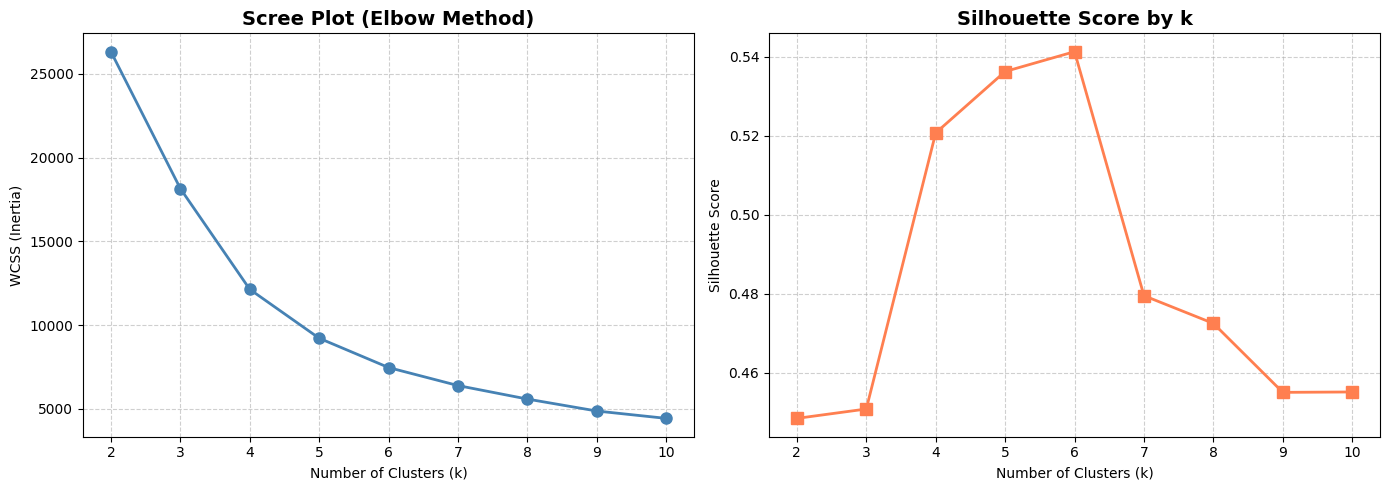

Cluster Distribution:
Cluster_Label
0    4047
1    1951
2    3342
3      30
Name: count, dtype: int64

LRFM Patterns per Cluster:
  Cluster 0: L L L L
  Cluster 1: L H L L
  Cluster 2: H L H H
  Cluster 3: H L H H

Comprehensive Cluster Analysis Table
                                                                                                                                                                                   Cluster 0                                                                                                                                                      Cluster 1                                                                                                                                                              Cluster 2                                                                                                                                      Cluster 3
LRFM Pattern                                                                              

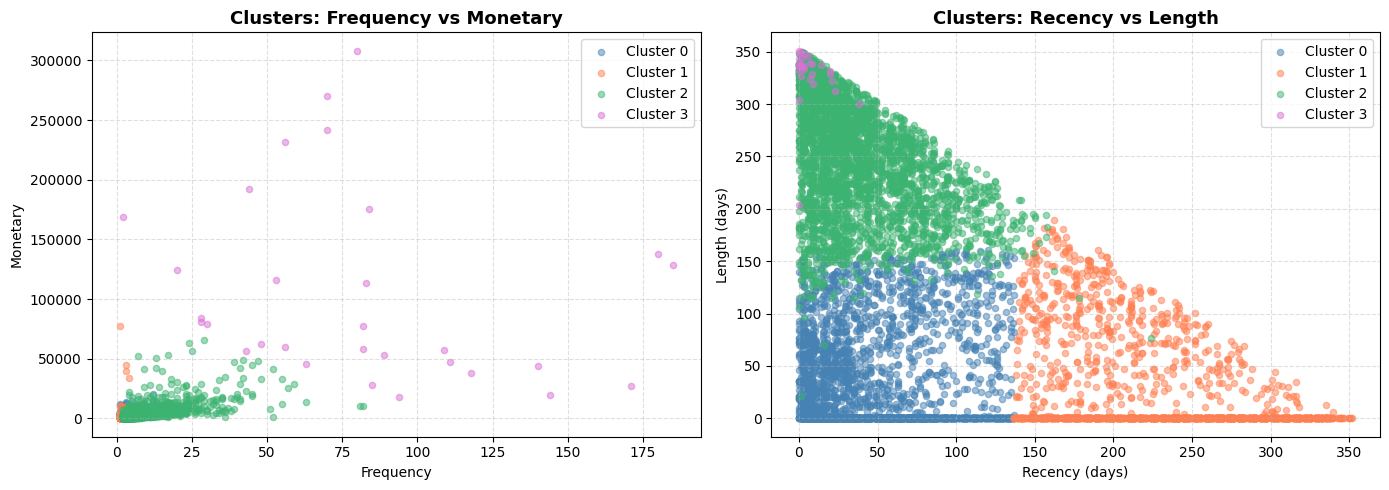


Full Dataset Shape: (7752, 15)
Saved: full_dataset.csv


In [ ]:
#K-Means Clustering on LRFM Variables (Predict Clusters)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# STEP 1: Load datasets
# ============================================================
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
full_dataset = pd.read_csv('rest_data.csv')
full_dataset['Customer ID'] = full_dataset['Customer ID'].astype(str)

if 'Cluster_Label' in full_dataset.columns:
    full_dataset = full_dataset.drop(columns=['Cluster_Label'])

# ============================================================
# STEP 2: Compute LRFM variables per customer per year
# ============================================================
year_end = (
    df_clean.groupby('Year')['InvoiceDate']
    .max()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Year_End_Date'})
)

lrfm_records = []

for year, group in df_clean.groupby('Year'):
    year_end_date = pd.Timestamp(year_end[year_end['Year'] == year]['Year_End_Date'].values[0])

    customer_agg = (
        group.groupby('Customer ID')
        .agg(
            First_Purchase=('InvoiceDate', 'min'),
            Last_Purchase=('InvoiceDate', 'max'),
            Frequency=('Invoice', 'nunique'),
            Monetary=('TotalPrice', 'sum')
        )
        .reset_index()
    )

    customer_agg['Length'] = (
        customer_agg['Last_Purchase'] - customer_agg['First_Purchase']
    ).dt.days

    customer_agg['Recency'] = (
        year_end_date - customer_agg['Last_Purchase']
    ).dt.days

    customer_agg['Year'] = year
    lrfm_records.append(customer_agg)

lrfm_df = pd.concat(lrfm_records, ignore_index=True)
lrfm_df['Customer ID'] = lrfm_df['Customer ID'].astype(str)
lrfm_df['Monetary'] = lrfm_df['Monetary'].round(2)

# ============================================================
# STEP 3: Standardize & Scree Plot
# ============================================================
features = ['Length', 'Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
lrfm_scaled = scaler.fit_transform(lrfm_df[features])

wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(lrfm_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(lrfm_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Scree Plot (Elbow Method)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(k_range, silhouette_scores, marker='s', color='coral', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by k', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 4: Fit KMeans with optimal k=4
# ============================================================
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
lrfm_df['Cluster_Label'] = kmeans_final.fit_predict(lrfm_scaled)

print("Cluster Distribution:")
print(lrfm_df['Cluster_Label'].value_counts().sort_index())

# ============================================================
# STEP 5: Merge Cluster_Label + all needed columns into
#         full_dataset for the table
# ============================================================
cluster_lookup = lrfm_df[['Customer ID', 'Year', 'Cluster_Label',
                            'Length', 'Recency']].copy()

full_dataset = full_dataset.merge(cluster_lookup, on=['Customer ID', 'Year'], how='left')
full_dataset['Cluster_Label'] = full_dataset['Cluster_Label'].fillna(-1).astype(int)

# Keep only valid clusters (drop -1)
df_table = full_dataset[full_dataset['Cluster_Label'] >= 0].copy()

# ============================================================
# STEP 6: Identify LRFM pattern per cluster
#         Green (high) = above overall mean
#         Red  (low)   = below overall mean
# ============================================================
overall_means = lrfm_df[features].mean()

cluster_lrfm = lrfm_df[lrfm_df['Cluster_Label'] >= 0].groupby('Cluster_Label')[features].mean()

def lrfm_pattern(cluster_means, overall_means):
    """Returns H/L pattern for L, R, F, M"""
    pattern = []
    for feat in features:
        if cluster_means[feat] >= overall_means[feat]:
            pattern.append('H')
        else:
            pattern.append('L')
    return ' '.join(pattern)

patterns = {
    c: lrfm_pattern(cluster_lrfm.loc[c], overall_means)
    for c in cluster_lrfm.index
}

print("\nLRFM Patterns per Cluster:")
for c, p in patterns.items():
    print(f"  Cluster {c}: {p}")

# ============================================================
# STEP 7: Build Cluster Analysis Table
# ============================================================
cluster_ids = sorted(df_table['Cluster_Label'].unique())
table_data = {}

for c in cluster_ids:
    sub = df_table[df_table['Cluster_Label'] == c]
    col = {}

    # LRFM Pattern
    col['LRFM Pattern'] = patterns[c]

    # Number of customers (unique)
    col['No. of Customers'] = sub['Customer ID'].nunique()

    # Avg Length & Recency (from lrfm_df)
    lrfm_sub = lrfm_df[lrfm_df['Cluster_Label'] == c]
    col['Avg. Length (Days)'] = round(lrfm_sub['Length'].mean(), 2)
    col['Avg. Recency (Days)'] = round(lrfm_sub['Recency'].mean(), 2)

    # Province — top 4
    if 'Province' in sub.columns:
        prov_counts = sub['Province'].value_counts(normalize=True) * 100
        top_prov = prov_counts.head(4)
        col['Province (Top 4)'] = ', '.join(
            [f"{p}({v:.2f}%)" for p, v in top_prov.items()]
        )

    # Best Selling Product — top 4
    if 'Best_Selling_Product' in sub.columns:
        prod_counts = sub['Best_Selling_Product'].value_counts(normalize=True) * 100
        top_prod = prod_counts.head(4)
        col['Best Selling Product (Top 4)'] = ', '.join(
            [f"{p}({v:.2f}%)" for p, v in top_prod.items()]
        )

    # Market Group distribution
    if 'Market_Group' in sub.columns:
        mg_counts = sub['Market_Group'].value_counts(normalize=True) * 100
        for mg in sub['Market_Group'].dropna().unique():
            col[f'Market Group: {mg}'] = f"{mg_counts.get(mg, 0):.2f}%"

    # Customer State distribution
    if 'Customer_State' in sub.columns:
        cs_counts = sub['Customer_State'].value_counts(normalize=True) * 100
        for state in ['Active', 'Inactive', 'Churned']:
            col[f'Customer State: {state}'] = f"{cs_counts.get(state, 0):.2f}%"

    # Average CLV
    if 'CLV' in sub.columns:
        col['Average CLV ($)'] = f"${sub['CLV'].mean():.2f}"

    table_data[f'Cluster {c}'] = col

# Convert to DataFrame
summary_table = pd.DataFrame(table_data)
print("\n" + "=" * 80)
print("Comprehensive Cluster Analysis Table")
print("=" * 80)
print(summary_table.to_string())
print("=" * 80)

# ============================================================
# STEP 8: Save cluster analysis table to Excel
# ============================================================
summary_table.to_excel('cluster_analysis_table.xlsx')
print("\nSaved: cluster_analysis_table.xlsx")

# ============================================================
# STEP 9: Visualize clusters
# ============================================================
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in cluster_ids:
    subset = lrfm_df[lrfm_df['Cluster_Label'] == c]
    axes[0].scatter(subset['Frequency'], subset['Monetary'],
                    label=f'Cluster {c}', alpha=0.5, s=20, color=colors[c])
    axes[1].scatter(subset['Recency'], subset['Length'],
                    label=f'Cluster {c}', alpha=0.5, s=20, color=colors[c])

axes[0].set_title('Clusters: Frequency vs Monetary', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].set_title('Clusters: Recency vs Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Length (days)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('cluster_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 10: Save full_dataset
# ============================================================
full_dataset.to_csv('rest_data.csv', index=False)
print("\nFull Dataset Shape:", full_dataset.shape)
print("Saved: full_dataset.csv")

In [26]:
#K-Means Clustering on LRFM Variables - Summary Table

import pandas as pd
import numpy as np

# ============================================================
# STEP 1: Load datasets
# ============================================================
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year

full_dataset = pd.read_csv('rest_data.csv')
full_dataset['Customer ID'] = full_dataset['Customer ID'].astype(str)

# ============================================================
# STEP 2: Compute LRFM per customer per year
# ============================================================
year_end = (
    df_clean.groupby('Year')['InvoiceDate']
    .max()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Year_End_Date'})
)

lrfm_records = []
for year, group in df_clean.groupby('Year'):
    year_end_date = pd.Timestamp(
        year_end[year_end['Year'] == year]['Year_End_Date'].values[0]
    )
    customer_agg = (
        group.groupby('Customer ID')
        .agg(
            First_Purchase=('InvoiceDate', 'min'),
            Last_Purchase=('InvoiceDate', 'max'),
            Frequency=('Invoice', 'nunique'),
            Monetary=('TotalPrice', 'sum')
        )
        .reset_index()
    )
    customer_agg['Length']  = (customer_agg['Last_Purchase'] - customer_agg['First_Purchase']).dt.days
    customer_agg['Recency'] = (year_end_date - customer_agg['Last_Purchase']).dt.days
    customer_agg['Year']    = year
    lrfm_records.append(customer_agg)

lrfm_df = pd.concat(lrfm_records, ignore_index=True)
lrfm_df['Customer ID'] = lrfm_df['Customer ID'].astype(str)

print("LRFM df shape:", lrfm_df.shape)
print("LRFM columns:", lrfm_df.columns.tolist())

# ============================================================
# STEP 3: Merge LRFM into full_dataset FIRST
#         then merge Cluster_Label
# ============================================================

# Drop LRFM columns if they already exist in full_dataset
cols_to_drop = [c for c in ['Length', 'Recency',
                              'Frequency', 'Monetary'] 
                if c in full_dataset.columns]
if cols_to_drop:
    full_dataset = full_dataset.drop(columns=cols_to_drop)

# Merge LRFM variables
analysis_df = full_dataset.merge(
    lrfm_df[['Customer ID', 'Year', 'Length', 'Recency', 'Frequency', 'Monetary']],
    on=['Customer ID', 'Year'],
    how='left'
)

# Verify LRFM columns exist
print("\nanalysis_df columns after LRFM merge:")
print(analysis_df.columns.tolist())
print("\nLRFM null counts:")
print(analysis_df[['Length', 'Recency', 'Frequency', 'Monetary']].isnull().sum())

# Remove rows with invalid cluster labels
analysis_df = analysis_df[analysis_df['Cluster_Label'] >= 0].copy()

print("\nAnalysis df shape:", analysis_df.shape)
print("Clusters present:", sorted(analysis_df['Cluster_Label'].unique()))

# ============================================================
# STEP 4: Compute overall LRFM averages
# ============================================================
lrfm_vars = ['Length', 'Recency', 'Frequency', 'Monetary']

overall_avg = {
    'Length':    analysis_df['Length'].mean(),
    'Recency':   analysis_df['Recency'].mean(),
    'Frequency': analysis_df['Frequency'].mean(),
    'Monetary':  analysis_df['Monetary'].mean()
}

print("\nOverall LRFM Averages:")
for k, v in overall_avg.items():
    print(f"  {k}: {v:.2f}")

# ============================================================
# STEP 5: Build cluster summary
# ============================================================
clusters = sorted(analysis_df['Cluster_Label'].unique())
summary = {}

for cluster in clusters:
    cdf = analysis_df[analysis_df['Cluster_Label'] == cluster]
    col = {}

    col['No. of Customers']     = cdf['Customer ID'].nunique()
    col['Avg. Length (Days)']   = round(cdf['Length'].mean(), 2)
    col['Avg. Recency (Days)']  = round(cdf['Recency'].mean(), 2)
    col['Avg. Frequency']       = round(cdf['Frequency'].mean(), 2)
    col['Avg. Monetary ($)']    = round(cdf['Monetary'].mean(), 2)

    if 'CLV' in cdf.columns:
        col['Avg. CLV ($)'] = round(cdf['CLV'].mean(), 2)

    if 'Province' in cdf.columns:
        top3 = cdf['Province'].value_counts(normalize=True).head(3)
        for i, (p, v) in enumerate(top3.items(), 1):
            col[f'Province {i}'] = f"{p} ({v*100:.1f}%)"

    if 'Best_Selling_Product' in cdf.columns:
        top3p = cdf['Best_Selling_Product'].value_counts(normalize=True).head(3)
        for i, (p, v) in enumerate(top3p.items(), 1):
            col[f'Best Selling {i}'] = f"{p} ({v*100:.1f}%)"

    if 'Market_Group' in cdf.columns:
        for mg, v in cdf['Market_Group'].value_counts(normalize=True).items():
            col[f'Market: {mg}'] = f"{v*100:.1f}%"

    if 'Customer_State' in cdf.columns:
        for state in ['Active', 'Inactive', 'Churned', 'Unknown']:
            pct = (cdf['Customer_State'] == state).mean() * 100
            if pct > 0:
                col[f'State: {state}'] = f"{pct:.1f}%"

    summary[f'Cluster {cluster}'] = col

summary_df = pd.DataFrame(summary)
print("\nCluster Summary Table:")
print(summary_df.to_string())

# ============================================================
# STEP 6: LRFM Indicator Table (Green/Red per cluster)
# ============================================================
indicator_rows = {}
for var in lrfm_vars:
    row = {}
    for cluster in clusters:
        cdf        = analysis_df[analysis_df['Cluster_Label'] == cluster]
        clust_avg  = cdf[var].mean()
        overall    = overall_avg[var]

        # Recency: lower = more recent = better = Green
        if var == 'Recency':
            ind = '🟢' if clust_avg < overall else '🔴'
        else:
            ind = '🟢' if clust_avg >= overall else '🔴'

        row[f'Cluster {cluster}'] = f"{ind} {clust_avg:.1f}"
    indicator_rows[f'LRFM: {var}'] = row

indicator_df = pd.DataFrame(indicator_rows).T
print("\nLRFM Indicators (🟢 = Above Avg, 🔴 = Below Avg):")
print(indicator_df.to_string())

# ============================================================
# STEP 7: Save Excel
# ============================================================
with pd.ExcelWriter('cluster_analysis_table.xlsx', engine='openpyxl') as writer:

    # Sheet 1: Cluster Summary
    summary_df.to_excel(writer, sheet_name='Cluster Summary')

    # Sheet 2: LRFM Indicators
    indicator_df.to_excel(writer, sheet_name='LRFM Indicators')

    # Sheet 3: Detailed Stats
    detail_rows = []
    for cluster in clusters:
        cdf = analysis_df[analysis_df['Cluster_Label'] == cluster]
        row = {
            'Cluster':             f'Cluster {cluster}',
            'No. of Customers':    cdf['Customer ID'].nunique(),
            'Avg. Length (Days)':  round(cdf['Length'].mean(), 2),
            'Avg. Recency (Days)': round(cdf['Recency'].mean(), 2),
            'Avg. Frequency':      round(cdf['Frequency'].mean(), 2),
            'Avg. Monetary ($)':   round(cdf['Monetary'].mean(), 2),
        }
        if 'CLV' in cdf.columns:
            row['Avg. CLV ($)'] = round(cdf['CLV'].mean(), 2)
        for state in ['Active', 'Inactive', 'Churned', 'Unknown']:
            if 'Customer_State' in cdf.columns:
                row[f'% {state}'] = round((cdf['Customer_State'] == state).mean() * 100, 2)
        if 'Market_Group' in cdf.columns:
            for mg in analysis_df['Market_Group'].dropna().unique():
                row[f'% {mg}'] = round((cdf['Market_Group'] == mg).mean() * 100, 2)
        detail_rows.append(row)

    detail_df = pd.DataFrame(detail_rows).set_index('Cluster')
    detail_df.to_excel(writer, sheet_name='Detailed Stats')

    # Sheet 4: LRFM Raw Averages
    lrfm_avg_table = (
        analysis_df.groupby('Cluster_Label')[lrfm_vars]
        .mean().round(2)
    )
    lrfm_avg_table.index = [f'Cluster {c}' for c in lrfm_avg_table.index]
    overall_row = pd.DataFrame(
        [[overall_avg[v] for v in lrfm_vars]],
        columns=lrfm_vars,
        index=['Overall Average']
    )
    lrfm_avg_table = pd.concat([lrfm_avg_table, overall_row])
    lrfm_avg_table.to_excel(writer, sheet_name='LRFM Averages')

print("\nSaved: cluster_analysis_table.xlsx")

# ============================================================
# STEP 8: Console Summary
# ============================================================
print("\n" + "=" * 70)
print("CLUSTER ANALYSIS SUMMARY")
print("=" * 70)

for cluster in clusters:
    cdf = analysis_df[analysis_df['Cluster_Label'] == cluster]

    indicators = []
    for var in lrfm_vars:
        clust_avg = cdf[var].mean()
        overall   = overall_avg[var]
        if var == 'Recency':
            ind = '🟢' if clust_avg < overall else '🔴'
        else:
            ind = '🟢' if clust_avg >= overall else '🔴'
        indicators.append(f"{var[0]}{ind}")

    print(f"\n--- Cluster {cluster} | LRFM Pattern: {' '.join(indicators)} ---")
    print(f"  No. of Customers   : {cdf['Customer ID'].nunique()}")
    print(f"  Avg. Length (days) : {cdf['Length'].mean():.1f}")
    print(f"  Avg. Recency (days): {cdf['Recency'].mean():.1f}")
    print(f"  Avg. Frequency     : {cdf['Frequency'].mean():.1f}")
    print(f"  Avg. Monetary ($)  : {cdf['Monetary'].mean():.2f}")

    if 'CLV' in cdf.columns:
        print(f"  Avg. CLV ($)       : {cdf['CLV'].mean():.2f}")

    if 'Province' in cdf.columns:
        top3 = cdf['Province'].value_counts(normalize=True).head(3)
        print(f"  Top Provinces      : {', '.join([f'{p} ({v*100:.1f}%)' for p, v in top3.items()])}")

    if 'Best_Selling_Product' in cdf.columns:
        top3p = cdf['Best_Selling_Product'].value_counts(normalize=True).head(3)
        print(f"  Top Products       : {', '.join([f'{p} ({v*100:.1f}%)' for p, v in top3p.items()])}")

    if 'Market_Group' in cdf.columns:
        mg = cdf['Market_Group'].value_counts(normalize=True)
        print(f"  Market Groups      : {', '.join([f'{m} ({v*100:.1f}%)' for m, v in mg.items()])}")

    if 'Customer_State' in cdf.columns:
        cs = cdf['Customer_State'].value_counts(normalize=True)
        print(f"  Customer States    : {', '.join([f'{s} ({v*100:.1f}%)' for s, v in cs.items()])}")

print("\n" + "=" * 70)
print(f"Overall: L={overall_avg['Length']:.1f}d | R={overall_avg['Recency']:.1f}d | "
      f"F={overall_avg['Frequency']:.1f} | M=${overall_avg['Monetary']:.2f}")
print("=" * 70)

LRFM df shape: (9370, 8)
LRFM columns: ['Customer ID', 'First_Purchase', 'Last_Purchase', 'Frequency', 'Monetary', 'Length', 'Recency', 'Year']

analysis_df columns after LRFM merge:
['Customer ID', 'Year', 'Monetary_Value', 'Province', 'Best_Selling_Product', 'Market_Group', 'CLV', 'Length_x', 'Recency_x', 'Length_y', 'Recency_y', 'Cluster_Label', 'Length', 'Recency', 'Frequency', 'Monetary']

LRFM null counts:
Length       0
Recency      0
Frequency    0
Monetary     0
dtype: int64

Analysis df shape: (7752, 16)
Clusters present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Overall LRFM Averages:
  Length: 128.40
  Recency: 67.80
  Frequency: 4.51
  Monetary: 2130.10

Cluster Summary Table:
                                                             Cluster 0                                  Cluster 1                                  Cluster 2                                Cluster 3
No. of Customers                                                  2590                     

In [32]:
rest = pd.read_csv('rest_data.csv')
full = pd.read_csv('full_dataset.csv')

df_merged = (
    pd.merge(rest ,full, on="Customer ID", how="inner")
      .drop(columns=["pf_length", "recency"], errors="ignore")
      .loc[:, lambda df: ~df.columns.str.endswith('_y')]
)

df_merged.columns = df_merged.columns.str.replace('_x', '', regex=False)

df_merged = (
    df_merged.sort_values(["Customer ID", "Year"])
             .drop_duplicates(subset=["Customer ID", "Year"], keep="first")
)
df_merged.to_csv('full_data.csv', index=False)

In [11]:
"""
Stacking Ensemble Model for CLV Prediction – Restricted Dataset (v3)
=====================================================================
Changes vs v2:
  - Temporal split  : train=2009+2010, test=2011
  - All other requirements identical to v2:
      * Winsorization at 95th percentile (fitted on train only)
      * Best_Selling_Product DROPPED; Market_Group used
      * Elastic Net alpha=0.01
      * OHE for Elastic Net & SVM; Target-encode for RF & XGBoost
      * PCA applied to OHE branch only
      * RF & XGBoost: no PCA
      * Log-transforms on skewed numerics + target
      * Interaction feature: log_Frequency × log_Monetary_Value
      * No data leakage (scaler/winsor/encoder fitted on train only)
Architecture:
  Base learners : Elastic Net | Random Forest | XGBoost | SVM
  Meta-learner  : Linear Regression
Metrics: nRMSE, nMAE, R²
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("rest_data.csv")
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Years available: {sorted(df['Year'].unique())}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split  –  train: 2009+2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)
print(f"\nTrain (2009+2010): {len(train_df)} rows")
print(f"  2009: {(train_df['Year']==2009).sum()} rows")
print(f"  2010: {(train_df['Year']==2010).sum()} rows")
print(f"Test  (2011):      {len(test_df)} rows  "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Feature definitions
# ─────────────────────────────────────────────────────────────────────────────
KEEP_NUM = ["Frequency", "Monetary_Value"]
CAT_COLS = ["Province", "Market_Group"]
TARGET   = "CLV"

# ─────────────────────────────────────────────────────────────────────────────
# 3. Log-transform skewed numerics + target
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = KEEP_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

print(f"\nBefore Winsorization – Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. Winsorization at 95th percentile (fitted on TRAIN only)
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

# Target
lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

# Numeric features
for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

print(f"After  Winsorization – Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")
print(f"Train size after Winsorization: {len(train_df)}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Interaction feature
# ─────────────────────────────────────────────────────────────────────────────
train_df["log_freq_x_monetary"] = train_df["log_Frequency"] * train_df["log_Monetary_Value"]
test_df["log_freq_x_monetary"]  = test_df["log_Frequency"]  * test_df["log_Monetary_Value"]

NUM_FEATS = ["log_Frequency", "log_Monetary_Value", "log_freq_x_monetary"]

# ─────────────────────────────────────────────────────────────────────────────
# 6. Encoding
# ─────────────────────────────────────────────────────────────────────────────

def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df [NUM_FEATS + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df [NUM_FEATS + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 7. Feature / target matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

print(f"\nOHE feature matrix: {X_train_ohe.shape[1]} cols")
print(f"TE  feature matrix: {X_train_te.shape[1]} cols")

# ─────────────────────────────────────────────────────────────────────────────
# 8. Scaling (fit on train, apply to test)
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 9. PCA — OHE branch only
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"\nPCA (OHE branch): {X_train_ohe_sc.shape[1]} → {X_train_ohe_pca.shape[1]} components")
print(f"TE  branch       : {X_train_te_final.shape[1]} features (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 10. Metric helpers
# ─────────────────────────────────────────────────────────────────────────────
def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<42}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 11. Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
base_params = {
    "enet": dict(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "svm" : dict(C=1, epsilon=0.01, gamma="scale", kernel="rbf"),
    "rf"  : dict(n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 random_state=42, n_jobs=-1),
    "xgb" : dict(n_estimators=100, max_depth=6, learning_rate=0.3,
                 random_state=42, n_jobs=-1, verbosity=0),
}

# ─────────────────────────────────────────────────────────────────────────────
# 12. Train base learners on full train set → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE (predictions back-transformed to original scale)")
print("="*72)

enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(y_test_orig, np.expm1(enet_pred_log_test), "Elastic Net (alpha=0.01)")

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(y_test_orig, np.expm1(svm_pred_log_test), "SVM (TE, no PCA, eps=0.01)")

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(y_test_orig, np.expm1(rf_pred_log_test), "Random Forest (no PCA)")

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(X_train_te_final, y_train_log,
              eval_set=[(X_test_te_final, y_test_log)], verbose=False)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(y_test_orig, np.expm1(xgb_pred_log_test), "XGBoost (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 13. OOF meta-features (5-fold)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold) ...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 14. Meta-learner: Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
print("\nFitting meta-learner (Linear Regression) ...")
meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)
print(f"  Meta-learner weights: {dict(zip(['ElasticNet','SVM','RF','XGB'], meta_lr.coef_.round(4)))}")

stacking_pred_log = meta_lr.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING RESTRICTED MODEL (train=2009+2010)  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred, "Stacking Restricted Model")

# ─────────────────────────────────────────────────────────────────────────────
# 15. 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Restricted Model, train=2009+2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(**base_params["enet"])
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(**base_params["svm"])
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(**base_params["rf"])
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(**base_params["xgb"])
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(**base_params["enet"])
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(**base_params["svm"])
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(**base_params["rf"])
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(**base_params["xgb"])
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    m_cv = LinearRegression()
    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 16. Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",               **metrics_enet},
    {"Model": "SVM",                       **metrics_svm},
    {"Model": "Random Forest",             **metrics_rf},
    {"Model": "XGBoost",                   **metrics_xgb},
    {"Model": "Stacking Restricted Model", **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 17. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net":          np.expm1(enet_pred_log_test),
    "SVM":                  np.expm1(svm_pred_log_test),
    "Random Forest":        np.expm1(rf_pred_log_test),
    "XGBoost":              np.expm1(xgb_pred_log_test),
    "Stacking\nRestricted": stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual CLV", fontsize=9)
    ax.set_ylabel("Predicted CLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}", fontsize=9, fontweight="bold")

ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_data["Model"], rotation=30, ha="right", fontsize=8)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble – Restricted Model  |  Train: 2009+2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_restricted_v3_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved.")

# ─────────────────────────────────────────────────────────────────────────────
# 18. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_restricted_v3_metrics.csv")
cv_df.to_csv("stacking_restricted_v3_cv.csv", index=False)
print("CSVs saved.\nDone ✓")

Loaded 7752 rows × 8 cols
Years available: [np.int64(2009), np.int64(2010), np.int64(2011)]

Train (2009+2010): 4258 rows
  2009: 868 rows
  2010: 3390 rows
Test  (2011):      3494 rows  (45.1% of combined)

Before Winsorization – Train log-CLV: mean=6.227  std=1.011  skew=-0.636
After  Winsorization – Train log-CLV: mean=6.231  std=0.901  skew=-0.584
Train size after Winsorization: 4258

OHE feature matrix: 41 cols
TE  feature matrix: 5 cols

PCA (OHE branch): 41 → 37 components
TE  branch       : 5 features (no PCA)

BASE LEARNER PERFORMANCE (predictions back-transformed to original scale)
  Elastic Net (alpha=0.01)                    nRMSE=0.6517094  nMAE=0.0001339  R²=-0.045859
  SVM (TE, no PCA, eps=0.01)                  nRMSE=0.2892703  nMAE=0.0000565  R²=0.793950
  Random Forest (no PCA)                      nRMSE=0.3921053  nMAE=0.0000713  R²=0.621409
  XGBoost (no PCA)                            nRMSE=0.3840725  nMAE=0.0000695  R²=0.636762

Generating out-of-fold meta-feature

In [12]:
"""
Stacking Ensemble Model for CLV Prediction - FULL Dataset
==========================================================
Same architecture as Restricted Model but with 4 extra features:
  - Predicted_Purchases       (BG-NBD)
  - Predicted_Monetary_Value  (Gamma-Gamma)
  - Customer_State            (Markov Chain)
  - Cluster_Label             (K-Means)
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load Full Dataset
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"full_data.csv")
df.columns = df.columns.str.strip()

print(f"Loaded {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")
print(f"Years available: {sorted(df['Year'].unique())}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split — train: 2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)

print(f"\nTrain (2010): {len(train_df)} rows")
print(f"Test  (2011): {len(test_df)} rows "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Define feature groups
# ─────────────────────────────────────────────────────────────────────────────
TARGET   = "CLV"

# Numeric features — original
ORIG_NUM = ["Frequency", "Monetary_Value"]

# 4 NEW features added in Full Model
NEW_NUM  = ["Predicted_Purchases", "Predicted_Monetary_Value"]
NEW_CAT  = ["Customer_State"]          # Markov → encode
NEW_ORD  = ["Cluster_Label"]           # K-Means → treat as numeric

# Categorical features
CAT_COLS = ["Province", "Market_Group"]

# Drop columns not used in modeling
DROP_COLS = ["Customer ID", "Year", "Best_Selling_Product"]

# ─────────────────────────────────────────────────────────────────────────────
# 3. Encode Customer_State (Markov) — Label Encode
# ─────────────────────────────────────────────────────────────────────────────
# Active=2, Inactive=1, Churned=0
state_map = {"Active": 2, "Inactive": 1, "Churned": 0}

train_df["Customer_State_Enc"] = train_df["Customer_State"].map(state_map).fillna(1)
test_df["Customer_State_Enc"]  = test_df["Customer_State"].map(state_map).fillna(1)

print("\nCustomer_State encoding:")
print(train_df["Customer_State"].value_counts())

# ─────────────────────────────────────────────────────────────────────────────
# 4. Log-transform skewed numerics + target
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = ORIG_NUM + NEW_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

print(f"\nBefore Winsorization — Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Winsorization at 95th percentile (fitted on TRAIN only)
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

# Target
lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

# Numeric features
for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

print(f"After  Winsorization — Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. Interaction features
# ─────────────────────────────────────────────────────────────────────────────
# Original interaction
train_df["log_freq_x_monetary"] = (
    train_df["log_Frequency"] * train_df["log_Monetary_Value"]
)
test_df["log_freq_x_monetary"] = (
    test_df["log_Frequency"] * test_df["log_Monetary_Value"]
)

# NEW: Predicted purchases × predicted monetary value
train_df["log_pred_freq_x_monetary"] = (
    train_df["log_Predicted_Purchases"] *
    train_df["log_Predicted_Monetary_Value"]
)
test_df["log_pred_freq_x_monetary"] = (
    test_df["log_Predicted_Purchases"] *
    test_df["log_Predicted_Monetary_Value"]
)

# All numeric features for modeling
NUM_FEATS = [
    "log_Frequency",
    "log_Monetary_Value",
    "log_freq_x_monetary",
    "log_Predicted_Purchases",          # NEW
    "log_Predicted_Monetary_Value",     # NEW
    "log_pred_freq_x_monetary",         # NEW interaction
    "Customer_State_Enc",               # NEW (Markov)
    "Cluster_Label",                    # NEW (K-Means)
]

print(f"\nTotal numeric features: {len(NUM_FEATS)}")
print(f"Features: {NUM_FEATS}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. Encoding
# ─────────────────────────────────────────────────────────────────────────────

# 7a. One-Hot Encoding (Elastic Net & SVM)
def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

# 7b. Smoothed Target Encoding (RF & XGBoost)
def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

# Build working copies — OHE branch
train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

# Build working copies — Target Encode branch
train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 8. Feature / target matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

print(f"\nOHE feature matrix: {X_train_ohe.shape[1]} cols")
print(f"TE  feature matrix: {X_train_te.shape[1]} cols")

# ─────────────────────────────────────────────────────────────────────────────
# 9. Scaling (fit on train only — no leakage)
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 10. PCA — OHE branch only (Elastic Net & SVM)
#     SKIP for RF & XGBoost (tree models don't need PCA)
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"\nPCA (OHE branch): {X_train_ohe_sc.shape[1]} → "
      f"{X_train_ohe_pca.shape[1]} components")
print(f"TE  branch       : {X_train_te_final.shape[1]} features (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 11. Metric helpers (paper definitions)
# ─────────────────────────────────────────────────────────────────────────────
def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<45}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 12. Hyperparameters (same as restricted model — paper Table 4)
# ─────────────────────────────────────────────────────────────────────────────
base_params = {
    "enet": dict(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "svm" : dict(C=1, epsilon=0.01, gamma="scale", kernel="rbf"),
    "rf"  : dict(n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 random_state=42, n_jobs=-1),
    "xgb" : dict(n_estimators=100, max_depth=6, learning_rate=0.3,
                 random_state=42, n_jobs=-1, verbosity=0),
}

# ─────────────────────────────────────────────────────────────────────────────
# 13. Train base learners on full train → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE — FULL MODEL (train=2010, test=2011)")
print("="*72)

enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(
    y_test_orig, np.expm1(enet_pred_log_test), "Elastic Net"
)

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(
    y_test_orig, np.expm1(svm_pred_log_test), "SVM"
)

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(
    y_test_orig, np.expm1(rf_pred_log_test), "Random Forest"
)

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(
    X_train_te_final, y_train_log,
    eval_set=[(X_test_te_final, y_test_log)],
    verbose=False
)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(
    y_test_orig, np.expm1(xgb_pred_log_test), "XGBoost"
)

# ─────────────────────────────────────────────────────────────────────────────
# 14. OOF meta-features (5-fold) — no leakage into meta-learner
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold)...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 15. Meta-learner: Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
print("\nFitting meta-learner (Linear Regression)...")
meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)

print(f"  Meta-learner weights: "
      f"{dict(zip(['ElasticNet','SVM','RF','XGB'], meta_lr.coef_.round(4)))}")

stacking_pred_log = meta_lr.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING FULL MODEL  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred, "Stacking Full Model")

# ─────────────────────────────────────────────────────────────────────────────
# 16. 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Full Model, train=2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(**base_params["enet"])
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(**base_params["svm"])
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(**base_params["rf"])
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(**base_params["xgb"])
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(**base_params["enet"])
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(**base_params["svm"])
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(**base_params["rf"])
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(**base_params["xgb"])
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    m_cv = LinearRegression()
    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 17. Summary Table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",          **metrics_enet},
    {"Model": "SVM",                  **metrics_svm},
    {"Model": "Random Forest",        **metrics_rf},
    {"Model": "XGBoost",              **metrics_xgb},
    {"Model": "Stacking Full Model",  **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 18. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net"     : np.expm1(enet_pred_log_test),
    "SVM"             : np.expm1(svm_pred_log_test),
    "Random Forest"   : np.expm1(rf_pred_log_test),
    "XGBoost"         : np.expm1(xgb_pred_log_test),
    "Stacking\nFull"  : stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual CLV", fontsize=9)
    ax.set_ylabel("Predicted CLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(
        f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}",
        fontsize=9, fontweight="bold"
    )

# Metric comparison bar chart
ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    bar_data["Model"], rotation=30, ha="right", fontsize=8
)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble — Full Model  |  Train: 2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_full_model_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved: stacking_full_model_results.png")

# ─────────────────────────────────────────────────────────────────────────────
# 19. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_full_model_metrics.csv")
cv_df.to_csv("stacking_full_model_cv.csv", index=False)
print("CSVs saved.")
print("Done ✓")

Loaded 7752 rows x 12 cols
Columns: ['Customer ID', 'Year', 'Frequency', 'Monetary_Value', 'Province', 'Best_Selling_Product', 'Market_Group', 'CLV', 'Predicted_Purchases', 'Predicted_Monetary_Value', 'Customer_State', 'Cluster_Label']
Years available: [np.int64(2009), np.int64(2010), np.int64(2011)]

Train (2010): 4258 rows
Test  (2011): 3494 rows (45.1% of combined)

Customer_State encoding:
Customer_State
Active      3946
Inactive     312
Name: count, dtype: int64

Before Winsorization — Train log-CLV: mean=6.227  std=1.011  skew=-0.636
After  Winsorization — Train log-CLV: mean=6.231  std=0.901  skew=-0.584

Total numeric features: 8
Features: ['log_Frequency', 'log_Monetary_Value', 'log_freq_x_monetary', 'log_Predicted_Purchases', 'log_Predicted_Monetary_Value', 'log_pred_freq_x_monetary', 'Customer_State_Enc', 'Cluster_Label']

OHE feature matrix: 46 cols
TE  feature matrix: 10 cols

PCA (OHE branch): 46 → 40 components
TE  branch       : 10 features (no PCA)

BASE LEARNER PERFOR

In [14]:
pip install shap

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------- ----------------------- 225.3/554.9 kB 6.9 MB/s eta 0:00:01
   ---------------------------------------  553.0/554.9 kB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 554.9/554.9 kB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.4 kB ? eta -:--:--
   ---------------------------------------- 78.4/78.4 kB ? eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/38.1 MB 7.0 MB/s eta 0:00:06
   ---------------------------------------- 0.3/38.1 MB 3.9 MB/s eta 0:00:10
   ---------------------------------------- 0.3/38.1 MB 3.5 MB/s eta 0:00:11
   ---------------------------------------- 0.5/38.1 MB 3.0 MB/s eta 0:00:13
    --------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
"""
SHAP Sensitivity Analysis — Stacking Full Model
================================================
Reproduces the full stacking model from the paper, then runs SHAP
analysis to produce:
  - shap_summary_full_dataset.png
  - shap_bar_plot_full_dataset.png
  - feature_importance_full_dataset.csv
  - shap_force_example.png
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load data
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("full_data.csv")
df.columns = df.columns.str.strip()
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Years: {sorted(df['Year'].unique())}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)
print(f"Train: {len(train_df)}  |  Test: {len(test_df)}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Feature engineering
# ─────────────────────────────────────────────────────────────────────────────
TARGET   = "CLV"
ORIG_NUM = ["Frequency", "Monetary_Value"]
NEW_NUM  = ["Predicted_Purchases", "Predicted_Monetary_Value"]
CAT_COLS = ["Province", "Market_Group"]
LOG_NUM  = ORIG_NUM + NEW_NUM

state_map = {"Active": 2, "Inactive": 1, "Churned": 0}
train_df["Customer_State_Enc"] = train_df["Customer_State"].map(state_map).fillna(1)
test_df["Customer_State_Enc"]  = test_df["Customer_State"].map(state_map).fillna(1)

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

for col in [log_target] + [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

train_df["log_freq_x_monetary"]      = train_df["log_Frequency"] * train_df["log_Monetary_Value"]
test_df["log_freq_x_monetary"]       = test_df["log_Frequency"]  * test_df["log_Monetary_Value"]
train_df["log_pred_freq_x_monetary"] = train_df["log_Predicted_Purchases"] * train_df["log_Predicted_Monetary_Value"]
test_df["log_pred_freq_x_monetary"]  = test_df["log_Predicted_Purchases"]  * test_df["log_Predicted_Monetary_Value"]

NUM_FEATS = [
    "log_Frequency",
    "log_Monetary_Value",
    "log_freq_x_monetary",
    "log_Predicted_Purchases",
    "log_Predicted_Monetary_Value",
    "log_pred_freq_x_monetary",
    "Customer_State_Enc",
    "Cluster_Label",
]

# ─────────────────────────────────────────────────────────────────────────────
# 3. Encoding
# ─────────────────────────────────────────────────────────────────────────────
def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (agg["count"] * agg["mean"] + smoothing * global_mean) / (agg["count"] + smoothing)
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

train_te = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te  = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 4. Matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

# ─────────────────────────────────────────────────────────────────────────────
# 5. Scaling & PCA
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()
X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)
X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

pca_ohe = PCA(n_components=0.99, random_state=RANDOM_STATE)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"OHE PCA components: {X_train_ohe_pca.shape[1]}  |  TE features: {X_train_te_final.shape[1]}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. Base learner hyperparameters (paper Table 4)
# ─────────────────────────────────────────────────────────────────────────────
base_params = {
    "enet": dict(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "svm" : dict(C=1, epsilon=0.01, gamma="scale", kernel="rbf"),
    "rf"  : dict(n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 random_state=RANDOM_STATE, n_jobs=-1),
    "xgb" : dict(n_estimators=100, max_depth=6, learning_rate=0.3,
                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

# ─────────────────────────────────────────────────────────────────────────────
# 7. Train base learners on full training set
# ─────────────────────────────────────────────────────────────────────────────
print("\nTraining base learners on full training set...")
enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_test = enet_model.predict(X_test_ohe_pca)

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_test = svm_model.predict(X_test_te_final)

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_test = rf_model.predict(X_test_te_final)

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(X_train_te_final, y_train_log,
              eval_set=[(X_test_te_final, y_test_log)], verbose=False)
xgb_pred_test = xgb_model.predict(X_test_te_final)
print("Base learners trained.")

# ─────────────────────────────────────────────────────────────────────────────
# 8. OOF meta-features (5-fold, no leakage)
# ─────────────────────────────────────────────────────────────────────────────
print("Generating OOF meta-features (5-fold)...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])
    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([enet_pred_test, svm_pred_test, rf_pred_test, xgb_pred_test])
META_NAMES   = ["ElasticNet_pred", "SVM_pred", "RF_pred", "XGB_pred"]

# ─────────────────────────────────────────────────────────────────────────────
# 9. Meta-learner (Linear Regression)
# ─────────────────────────────────────────────────────────────────────────────
meta_scaler     = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)
stacking_pred = np.expm1(meta_lr.predict(X_meta_test_sc))
r2 = r2_score(y_test_orig, stacking_pred)
print(f"\nStacking Full Model  R² = {r2:.6f}")
print(f"Meta-weights: { dict(zip(META_NAMES, meta_lr.coef_.round(4))) }")

# ─────────────────────────────────────────────────────────────────────────────
# 10. SHAP Analysis
#     Two layers as in the paper:
#       (a) XGBoost base learner  → raw feature sensitivity (TreeExplainer)
#       (b) Meta-learner          → base-learner contribution (KernelExplainer)
# ─────────────────────────────────────────────────────────────────────────────


# ── (a) XGBoost base learner – TreeExplainer ─────────────────────────────────
print("\n── SHAP: XGBoost base learner (TreeExplainer) ──")
sample_size = min(1000, len(X_test_te_final))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx  = rng.choice(len(X_test_te_final), sample_size, replace=False)
X_shap      = X_test_te_final[sample_idx]
X_shap_df   = pd.DataFrame(X_shap, columns=te_feat_cols)

xgb_explainer   = shap.TreeExplainer(xgb_model)
shap_values_xgb = xgb_explainer.shap_values(X_shap)

# Feature importance table
mean_abs_shap = np.abs(shap_values_xgb).mean(axis=0)
feature_importance_df = (
    pd.DataFrame({"Feature": te_feat_cols, "Mean_SHAP_Value": mean_abs_shap})
    .sort_values("Mean_SHAP_Value", ascending=False)
    .reset_index(drop=True)
)
feature_importance_df.to_csv("feature_importance_full_dataset.csv", index=False)
print("Saved: feature_importance_full_dataset.csv")

# ── (b) Meta-learner – KernelExplainer ───────────────────────────────────────
print("── SHAP: Meta-learner (KernelExplainer) ──")
bg_idx   = np.random.RandomState(RANDOM_STATE).choice(len(X_meta_train_sc),
                                                        min(150, len(X_meta_train_sc)),
                                                        replace=False)
bg_meta  = X_meta_train_sc[bg_idx]
meta_exp = shap.KernelExplainer(meta_lr.predict, bg_meta)
shap_meta = meta_exp.shap_values(X_meta_test_sc[:500], silent=True)

fi_meta = (
    pd.DataFrame({"Feature": META_NAMES,
                  "Mean_SHAP_Value": np.abs(shap_meta).mean(axis=0)})
    .sort_values("Mean_SHAP_Value", ascending=False)
    .reset_index(drop=True)
)
print("Meta-learner SHAP importance:")
print(fi_meta.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# 11. Plots
# ─────────────────────────────────────────────────────────────────────────────
BG = "#FAFAFA"

# ── A. SHAP Summary Plot (beeswarm) ──────────────────────────────────────────
print("\nGenerating SHAP summary plot...")
plt.figure(figsize=(11, 7))
plt.gcf().patch.set_facecolor(BG)
shap.summary_plot(shap_values_xgb, X_shap_df,
                  feature_names=te_feat_cols, show=False, plot_size=None)
plt.title("SHAP Summary Plot — Stacking Full Model\n(XGBoost base learner, raw features)",
          fontsize=14, fontweight="bold", pad=12)
plt.xlabel("SHAP value  (impact on log-CLV prediction)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_summary_full_dataset.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.close()
print("Saved: shap_summary_full_dataset.png")

# ── B. SHAP Bar Plot ──────────────────────────────────────────────────────────
print("Generating SHAP bar plot...")
top_n = min(15, len(feature_importance_df))
top   = feature_importance_df.head(top_n)

palette = ["#1a3a5c", "#1f5f99", "#2980c4",
           "#4a90d9", "#6aaed6", "#93c6e7"] + ["#bdd7ee"] * 20
colors  = palette[:top_n]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(range(top_n), top["Mean_SHAP_Value"].values,
               color=colors, edgecolor="white", linewidth=0.5, height=0.65)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top["Feature"].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|  (average impact on model output magnitude)", fontsize=11)
ax.set_title(f"Feature Importance — Top {top_n} Features\n"
             "Stacking Full Model (SHAP, XGBoost base learner)",
             fontsize=14, fontweight="bold")

max_val = top["Mean_SHAP_Value"].max()
for bar, val in zip(bars, top["Mean_SHAP_Value"].values):
    ax.text(bar.get_width() + max_val * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.5f}", va="center", ha="left", fontsize=9, color="#222222")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("shap_bar_plot_full_dataset.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.close()
print("Saved: shap_bar_plot_full_dataset.png")

# ── C. SHAP Force Plot (single observation) ───────────────────────────────────
print("Generating SHAP force plot...")
expected_val = xgb_explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = float(expected_val[0])

shap.force_plot(expected_val,
                shap_values_xgb[0],
                X_shap_df.iloc[0],
                matplotlib=True,
                show=False,
                figsize=(18, 4))
plt.title("SHAP Force Plot — Single Observation (index 0)",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("shap_force_example.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved: shap_force_example.png")

# ── D. Meta-learner importance bar (bonus) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
meta_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
ax.barh(fi_meta["Feature"], fi_meta["Mean_SHAP_Value"],
        color=meta_colors[:len(fi_meta)], edgecolor="white", height=0.5)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("Meta-learner: Contribution of Each Base Learner to Final CLV",
             fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("shap_meta_learner_importance.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.close()
print("Saved: shap_meta_learner_importance.png")

# ─────────────────────────────────────────────────────────────────────────────
# 12. Plain-English Interpretation
# ─────────────────────────────────────────────────────────────────────────────
top3    = feature_importance_df.head(5)
bottom2 = feature_importance_df.tail(2)

print("\n" + "=" * 65)
print("SENSITIVITY ANALYSIS — INTERPRETATION")
print("=" * 65)
print("\nThe model is most sensitive to:")
for _, row in top3.iterrows():
    print(f"  * {row['Feature']}  (Mean |SHAP| = {row['Mean_SHAP_Value']:.6f})")
print("\nThese variables have the largest impact on predicted CLV.")
print("\nThe least influential features are:")
for _, row in bottom2.iterrows():
    print(f"  * {row['Feature']}  (Mean |SHAP| = {row['Mean_SHAP_Value']:.6f})")
print("\n" + "=" * 65)
print("\nTop 5 most influential features (ranked):")
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {i}. {row['Feature']:<45s}  Mean |SHAP| = {row['Mean_SHAP_Value']:.7f}")
print("\nDone.")

Loaded 7752 rows x 12 cols
Years: [np.int64(2009), np.int64(2010), np.int64(2011)]
Train: 4258  |  Test: 3494
OHE PCA components: 40  |  TE features: 10

Training base learners on full training set...
Base learners trained.
Generating OOF meta-features (5-fold)...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done


Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  Fold 5/5 done

Stacking Full Model  R² = 0.723571
Meta-weights: {'ElasticNet_pred': np.float64(-0.0294), 'SVM_pred': np.float64(0.3033), 'RF_pred': np.float64(0.0892), 'XGB_pred': np.float64(0.4154)}

── SHAP: XGBoost base learner (TreeExplainer) ──
Saved: feature_importance_full_dataset.csv
── SHAP: Meta-learner (KernelExplainer) ──
Meta-learner SHAP importance:
        Feature  Mean_SHAP_Value
       XGB_pred         0.380948
       SVM_pred         0.262283
        RF_pred         0.079766
ElasticNet_pred         0.029104

Generating SHAP summary plot...
Saved: shap_summary_full_dataset.png
Generating SHAP bar plot...
Saved: shap_bar_plot_full_dataset.png
Generating SHAP force plot...
Saved: shap_force_example.png
Saved: shap_meta_learner_importance.png

SENSITIVITY ANALYSIS — INTERPRETATION

The model is most sensitive to:
  * log_Monetary_Value  (Mean |SHAP| = 0.545250)
  * log_Frequency  (Mean |SHAP| = 0.173878)
  * log_Predicted_Monetary_Value  (Mean |SHAP| = 0.156898)
  * log

In [23]:
import pandas as pd
import numpy as np

ALPHA = 0.20

# ── Step 1: Load and clean raw transaction data ────────────────────────────
raw = pd.read_csv("online_retail_II.csv")
raw.columns = raw.columns.str.strip()
raw.rename(columns={"Price": "UnitPrice"}, inplace=True)

raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], format="mixed")
raw["Year"] = raw["InvoiceDate"].dt.year
raw["Revenue"] = raw["Quantity"] * raw["UnitPrice"]

raw = raw.dropna(subset=["Customer ID"])
raw["Customer ID"] = raw["Customer ID"].astype(int)
raw = raw[raw["Revenue"] > 0]
raw = raw[raw["Quantity"] > 0]

raw = raw.sort_values(["Customer ID", "Year", "InvoiceDate"]).reset_index(drop=True)

# ── Step 2: Compute FirstPurchaseRevenue per Customer per Year ─────────────
# Sum all line-items per invoice first, then pick the earliest invoice per customer-year
invoice_totals = (
    raw.groupby(["Customer ID", "Year", "Invoice"])
       .agg(InvoiceDate=("InvoiceDate", "first"),
            InvoiceRevenue=("Revenue", "sum"))
       .reset_index()
)

first_purchase = (
    invoice_totals
    .sort_values(["Customer ID", "Year", "InvoiceDate"])
    .groupby(["Customer ID", "Year"])
    .first()
    .reset_index()
    [["Customer ID", "Year", "InvoiceRevenue"]]
)
first_purchase.rename(columns={"InvoiceRevenue": "FirstPurchaseRevenue"}, inplace=True)

# ── Step 3: Builder function ───────────────────────────────────────────────
def build_output(df):
    df = df.copy()
    df.dropna(subset=["Customer ID", "Year", "CLV"], inplace=True)
    df["Customer ID"] = df["Customer ID"].astype(int)
    df["Year"] = df["Year"].astype(int)

    merged = df.merge(first_purchase, on=["Customer ID", "Year"], how="left")

    merged = merged[merged["FirstPurchaseRevenue"].notna()]
    merged = merged[merged["FirstPurchaseRevenue"] > 0]

    merged["CAC"] = ALPHA * merged["FirstPurchaseRevenue"]
    merged["ProfitCLV"] = merged["CLV"] - merged["CAC"]

    merged.drop(columns=["CLV"], inplace=True)

    merged.sort_values(["Customer ID", "Year"], inplace=True)
    merged.reset_index(drop=True, inplace=True)
    return merged

# ── Step 4: Process both datasets ─────────────────────────────────────────
rest_raw = pd.read_csv("rest_data.csv")
full_raw = pd.read_csv("full_data.csv")

rest_out = build_output(rest_raw)
full_out = build_output(full_raw)

rest_out.to_csv("restricted_dataset_profit_clv.csv", index=False)
full_out.to_csv("full_dataset_profit_clv.csv", index=False)

# ── Step 5: Summary statistics ─────────────────────────────────────────────
def print_summary(df, label):
    print(f"\n{'='*60}")
    print(f"  SUMMARY — {label}")
    print(f"{'='*60}")

    print(f"\n  Rows: {len(df):,}  |  Unique Customers: {df['Customer ID'].nunique():,}")

    print("\n[1] Number of Customers per Year")
    print(df.groupby("Year")["Customer ID"].nunique().to_string())

    yearly = df.groupby("Year")[["FirstPurchaseRevenue", "CAC", "ProfitCLV"]].mean()

    print("\n[2] Mean FirstPurchaseRevenue per Year")
    print(yearly["FirstPurchaseRevenue"].round(4).to_string())

    print("\n[3] Mean CAC per Year")
    print(yearly["CAC"].round(4).to_string())

    print("\n[4] Mean ProfitCLV per Year")
    print(yearly["ProfitCLV"].round(4).to_string())

    print("\n[5] Overall Descriptive Statistics")
    for col in ["FirstPurchaseRevenue", "CAC", "ProfitCLV"]:
        s = df[col]
        print(f"\n  {col}:")
        print(f"    Mean   : {s.mean():.4f}")
        print(f"    Median : {s.median():.4f}")
        print(f"    Std    : {s.std():.4f}")
        print(f"    Min    : {s.min():.4f}")
        print(f"    Max    : {s.max():.4f}")

print_summary(rest_out, "RESTRICTED DATASET")
print_summary(full_out, "FULL DATASET")
print("\nDone.")


  SUMMARY — RESTRICTED DATASET

  Rows: 4,344  |  Unique Customers: 3,580

[1] Number of Customers per Year
Year
2010     850
2011    3494

[2] Mean FirstPurchaseRevenue per Year
Year
2010    404.5741
2011    451.8166

[3] Mean CAC per Year
Year
2010    80.9148
2011    90.3633

[4] Mean ProfitCLV per Year
Year
2010    908.1412
2011    838.8451

[5] Overall Descriptive Statistics

  FirstPurchaseRevenue:
    Mean   : 442.5725
    Median : 304.9000
    Std    : 1332.4298
    Min    : 0.8500
    Max    : 77183.6000

  CAC:
    Mean   : 88.5145
    Median : 60.9800
    Std    : 266.4860
    Min    : 0.1700
    Max    : 15436.7200

  ProfitCLV:
    Mean   : 852.4044
    Median : 595.4750
    Std    : 3704.3240
    Min    : 11.5316
    Max    : 181487.6884

  SUMMARY — FULL DATASET

  Rows: 4,344  |  Unique Customers: 3,580

[1] Number of Customers per Year
Year
2010     850
2011    3494

[2] Mean FirstPurchaseRevenue per Year
Year
2010    404.5741
2011    451.8166

[3] Mean CAC per Year
Ye

In [ ]:
"""
Stacking Ensemble Model for CLV Prediction – Restricted Dataset (v4) (Hyperparameter Tuning Added)
=====================================================================
Changes vs v3:
  - Hyperparameter tuning added for ALL base learners and meta-learner:
      * Elastic Net  : GridSearchCV over alpha × l1_ratio
      * SVM          : RandomizedSearchCV over C × epsilon × gamma
      * Random Forest: RandomizedSearchCV over n_estimators × max_depth ×
                       min_samples_split × min_samples_leaf
      * XGBoost      : RandomizedSearchCV over n_estimators × max_depth ×
                       learning_rate × subsample × colsample_bytree
      * Meta-learner : GridSearchCV over Ridge / Lasso / ElasticNet α values
  - All tuning is performed on train set ONLY (no test leakage)
  - Best params printed for each model
  - All other requirements identical to v3:
      * Temporal split  : train=2009+2010, test=2011
      * Winsorization at 95th percentile (fitted on train only)
      * Best_Selling_Product DROPPED; Market_Group used
      * OHE for Elastic Net & SVM; Target-encode for RF & XGBoost
      * PCA applied to OHE branch only
      * RF & XGBoost: no PCA
      * Log-transforms on skewed numerics + target
      * Interaction feature: log_Frequency × log_Monetary_Value
      * No data leakage (scaler/winsor/encoder fitted on train only)
Architecture:
  Base learners : Elastic Net | Random Forest | XGBoost | SVM
  Meta-learner  : Ridge / Lasso / ElasticNet (best selected via CV)
Metrics: nRMSE, nMAE, R²
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import xgboost as xgb
from scipy.stats import loguniform, uniform, randint

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("rest_data.csv")
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Years available: {sorted(df['Year'].unique())}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split  –  train: 2009+2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)
print(f"\nTrain (2009+2010): {len(train_df)} rows")
print(f"  2009: {(train_df['Year']==2009).sum()} rows")
print(f"  2010: {(train_df['Year']==2010).sum()} rows")
print(f"Test  (2011):      {len(test_df)} rows  "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Feature definitions
# ─────────────────────────────────────────────────────────────────────────────
KEEP_NUM = ["Frequency", "Monetary_Value"]
CAT_COLS = ["Province", "Market_Group"]
TARGET   = "CLV"

# ─────────────────────────────────────────────────────────────────────────────
# 3. Log-transform skewed numerics + target
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = KEEP_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

print(f"\nBefore Winsorization – Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. Winsorization at 95th percentile (fitted on TRAIN only)
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

# Target
lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

# Numeric features
for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

print(f"After  Winsorization – Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")
print(f"Train size after Winsorization: {len(train_df)}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Interaction feature
# ─────────────────────────────────────────────────────────────────────────────
train_df["log_freq_x_monetary"] = train_df["log_Frequency"] * train_df["log_Monetary_Value"]
test_df["log_freq_x_monetary"]  = test_df["log_Frequency"]  * test_df["log_Monetary_Value"]

NUM_FEATS = ["log_Frequency", "log_Monetary_Value", "log_freq_x_monetary"]

# ─────────────────────────────────────────────────────────────────────────────
# 6. Encoding
# ─────────────────────────────────────────────────────────────────────────────

def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df [NUM_FEATS + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df [NUM_FEATS + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 7. Feature / target matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

print(f"\nOHE feature matrix: {X_train_ohe.shape[1]} cols")
print(f"TE  feature matrix: {X_train_te.shape[1]} cols")

# ─────────────────────────────────────────────────────────────────────────────
# 8. Scaling (fit on train, apply to test)
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 9. PCA — OHE branch only
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"\nPCA (OHE branch): {X_train_ohe_sc.shape[1]} → {X_train_ohe_pca.shape[1]} components")
print(f"TE  branch       : {X_train_te_final.shape[1]} features (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 10. Metric helpers
# ─────────────────────────────────────────────────────────────────────────────
def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<42}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 11. Hyperparameter Tuning  (train set only, 5-fold inner CV)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("HYPERPARAMETER TUNING  (5-fold CV on train set)")
print("="*72)

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ── 11a. Elastic Net ─────────────────────────────────────────────────────────
print("\n[1/5] Elastic Net ...")
enet_param_grid = {
    "alpha"   : [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
}
enet_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    enet_param_grid,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0,
)
enet_search.fit(X_train_ohe_pca, y_train_log)
best_enet_params = enet_search.best_params_
print(f"  Best params : {best_enet_params}")
print(f"  Best CV RMSE: {-enet_search.best_score_:.6f}")

# ── 11b. SVM ─────────────────────────────────────────────────────────────────
print("\n[2/5] SVM ...")
svm_param_dist = {
    "C"      : loguniform(0.01, 100),
    "epsilon": loguniform(0.001, 1.0),
    "gamma"  : ["scale", "auto"] + list(loguniform(1e-4, 1.0).rvs(5, random_state=0)),
}
svm_search = RandomizedSearchCV(
    SVR(kernel="rbf"),
    svm_param_dist,
    n_iter=40,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
svm_search.fit(X_train_te_final, y_train_log)
best_svm_params = svm_search.best_params_
print(f"  Best params : {best_svm_params}")
print(f"  Best CV RMSE: {-svm_search.best_score_:.6f}")

# ── 11c. Random Forest ───────────────────────────────────────────────────────
print("\n[3/5] Random Forest ...")
rf_param_dist = {
    "n_estimators"    : randint(100, 600),
    "max_depth"       : [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf" : randint(1, 10),
    "max_features"     : ["sqrt", "log2", 0.5, 0.8, 1.0],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=40,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,          # outer parallelism off; RF itself uses n_jobs=-1
    random_state=42,
    verbose=0,
)
rf_search.fit(X_train_te_final, y_train_log)
best_rf_params = rf_search.best_params_
print(f"  Best params : {best_rf_params}")
print(f"  Best CV RMSE: {-rf_search.best_score_:.6f}")

# ── 11d. XGBoost ─────────────────────────────────────────────────────────────
print("\n[4/5] XGBoost ...")
xgb_param_dist = {
    "n_estimators"     : randint(100, 800),
    "max_depth"        : randint(3, 10),
    "learning_rate"    : loguniform(0.01, 0.5),
    "subsample"        : uniform(0.6, 0.4),       # 0.6 – 1.0
    "colsample_bytree" : uniform(0.5, 0.5),       # 0.5 – 1.0
    "min_child_weight" : randint(1, 10),
    "gamma"            : uniform(0, 0.5),
    "reg_alpha"        : loguniform(1e-4, 1.0),
    "reg_lambda"       : loguniform(1e-4, 10.0),
}
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=50,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    random_state=42,
    verbose=0,
)
xgb_search.fit(X_train_te_final, y_train_log)
best_xgb_params = xgb_search.best_params_
print(f"  Best params : {best_xgb_params}")
print(f"  Best CV RMSE: {-xgb_search.best_score_:.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 12. Train tuned base learners on full train set → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE (tuned, predictions back-transformed to original scale)")
print("="*72)

enet_model = ElasticNet(max_iter=10000, **best_enet_params)
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(y_test_orig, np.expm1(enet_pred_log_test),
                        f"Elastic Net (α={best_enet_params['alpha']}, "
                        f"l1={best_enet_params['l1_ratio']})")

svm_model = SVR(kernel="rbf", **best_svm_params)
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(y_test_orig, np.expm1(svm_pred_log_test),
                       f"SVM (C={best_svm_params['C']:.3f}, "
                       f"eps={best_svm_params['epsilon']:.4f})")

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(y_test_orig, np.expm1(rf_pred_log_test),
                      f"Random Forest (n={best_rf_params['n_estimators']}, "
                      f"depth={best_rf_params['max_depth']})")

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                              **best_xgb_params)
xgb_model.fit(X_train_te_final, y_train_log,
              eval_set=[(X_test_te_final, y_test_log)], verbose=False)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(y_test_orig, np.expm1(xgb_pred_log_test),
                       f"XGBoost (n={best_xgb_params['n_estimators']}, "
                       f"lr={best_xgb_params['learning_rate']:.4f})")

# ─────────────────────────────────────────────────────────────────────────────
# 13. OOF meta-features (5-fold, using tuned base learners)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold, tuned models) ...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(max_iter=10000, **best_enet_params)
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(kernel="rbf", **best_svm_params)
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                           **best_xgb_params)
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 14. Meta-learner: tuned via GridSearchCV over Ridge / Lasso / ElasticNet
# ─────────────────────────────────────────────────────────────────────────────
print("\n[5/5] Meta-learner tuning ...")

meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

# Candidate meta-learners: Ridge, Lasso, ElasticNet (positive=True optional)
alpha_vals = [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# Ridge
ridge_search = GridSearchCV(
    Ridge(),
    {"alpha": alpha_vals},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
ridge_search.fit(X_meta_train_sc, y_train_log)

# Lasso
lasso_search = GridSearchCV(
    Lasso(max_iter=10000),
    {"alpha": alpha_vals},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
lasso_search.fit(X_meta_train_sc, y_train_log)

# ElasticNet
meta_enet_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    {"alpha": alpha_vals, "l1_ratio": [0.25, 0.5, 0.75]},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
meta_enet_search.fit(X_meta_train_sc, y_train_log)

# Also try plain LinearRegression as baseline
lr_plain = LinearRegression()
from sklearn.model_selection import cross_val_score
lr_cv_score = cross_val_score(
    lr_plain, X_meta_train_sc, y_train_log,
    cv=inner_cv, scoring="neg_root_mean_squared_error"
).mean()

candidates = {
    "Ridge"        : (ridge_search.best_score_,     ridge_search.best_estimator_,
                      {"alpha": ridge_search.best_params_["alpha"]}),
    "Lasso"        : (lasso_search.best_score_,     lasso_search.best_estimator_,
                      {"alpha": lasso_search.best_params_["alpha"]}),
    "ElasticNet"   : (meta_enet_search.best_score_, meta_enet_search.best_estimator_,
                      meta_enet_search.best_params_),
    "LinearRegr"   : (lr_cv_score,                  lr_plain, {}),
}

best_meta_name  = max(candidates, key=lambda k: candidates[k][0])
best_meta_score = candidates[best_meta_name][0]
best_meta_model = candidates[best_meta_name][1]
best_meta_cfg   = candidates[best_meta_name][2]

print(f"\n  Meta-learner CV scores (neg RMSE):")
for name, (score, _, cfg) in candidates.items():
    marker = " ◄ BEST" if name == best_meta_name else ""
    print(f"    {name:<14}  {score:.6f}  {cfg}{marker}")

best_meta_model.fit(X_meta_train_sc, y_train_log)

if hasattr(best_meta_model, "coef_"):
    print(f"  Meta-learner weights: "
          f"{dict(zip(['ElasticNet','SVM','RF','XGB'], best_meta_model.coef_.round(4)))}")

stacking_pred_log = best_meta_model.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING RESTRICTED MODEL (train=2009+2010)  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred,
                         f"Stacking ({best_meta_name} meta-learner)")

# ─────────────────────────────────────────────────────────────────────────────
# 15. 5-Fold Cross-Validation  (using tuned models)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Restricted Model, train=2009+2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(max_iter=10000, **best_enet_params)
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(kernel="rbf", **best_svm_params)
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                               **best_xgb_params)
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(max_iter=10000, **best_enet_params)
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(kernel="rbf", **best_svm_params)
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                           **best_xgb_params)
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    # Re-instantiate best meta-learner type with best params
    if best_meta_name == "Ridge":
        m_cv = Ridge(**best_meta_cfg)
    elif best_meta_name == "Lasso":
        m_cv = Lasso(max_iter=10000, **best_meta_cfg)
    elif best_meta_name == "ElasticNet":
        m_cv = ElasticNet(max_iter=10000, **best_meta_cfg)
    else:
        m_cv = LinearRegression()

    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 16. Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",               **metrics_enet},
    {"Model": "SVM",                       **metrics_svm},
    {"Model": "Random Forest",             **metrics_rf},
    {"Model": "XGBoost",                   **metrics_xgb},
    {"Model": "Stacking Restricted Model", **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 17. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net":          np.expm1(enet_pred_log_test),
    "SVM":                  np.expm1(svm_pred_log_test),
    "Random Forest":        np.expm1(rf_pred_log_test),
    "XGBoost":              np.expm1(xgb_pred_log_test),
    "Stacking\nRestricted": stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual CLV", fontsize=9)
    ax.set_ylabel("Predicted CLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}", fontsize=9, fontweight="bold")

ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_data["Model"], rotation=30, ha="right", fontsize=8)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble – Restricted Model (Tuned)  |  Train: 2009+2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_restricted_v4_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved.")

# ─────────────────────────────────────────────────────────────────────────────
# 18. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_restricted_v4_metrics.csv")
cv_df.to_csv("stacking_restricted_v4_cv.csv", index=False)

# Save best hyperparameters for reference
best_params_df = pd.DataFrame([
    {"Model": "ElasticNet",   **best_enet_params},
    {"Model": "SVM",          **{k: str(v) for k, v in best_svm_params.items()}},
    {"Model": "RandomForest", **{k: str(v) for k, v in best_rf_params.items()}},
    {"Model": "XGBoost",      **{k: str(v) for k, v in best_xgb_params.items()}},
    {"Model": f"Meta ({best_meta_name})", **{k: str(v) for k, v in best_meta_cfg.items()}},
])
best_params_df.to_csv("stacking_restricted_v4_best_params.csv", index=False)
print("CSVs saved.\nDone ✓")

Loaded 7752 rows × 8 cols
Years available: [np.int64(2009), np.int64(2010), np.int64(2011)]

Train (2009+2010): 4258 rows
  2009: 868 rows
  2010: 3390 rows
Test  (2011):      3494 rows  (45.1% of combined)

Before Winsorization – Train log-CLV: mean=6.227  std=1.011  skew=-0.636
After  Winsorization – Train log-CLV: mean=6.231  std=0.901  skew=-0.584
Train size after Winsorization: 4258

OHE feature matrix: 41 cols
TE  feature matrix: 5 cols

PCA (OHE branch): 41 → 37 components
TE  branch       : 5 features (no PCA)

HYPERPARAMETER TUNING  (5-fold CV on train set)

[1/5] Elastic Net ...
  Best params : {'alpha': 0.01, 'l1_ratio': 0.75}
  Best CV RMSE: 0.747502

[2/5] SVM ...
  Best params : {'C': np.float64(2.754143921332031), 'epsilon': np.float64(0.31592553907017473), 'gamma': np.float64(0.01567667719550607)}
  Best CV RMSE: 0.603092

[3/5] Random Forest ...
  Best params : {'max_depth': 5, 'max_features': 1.0, 'min_samples_leaf': 8, 'min_samples_split': 14, 'n_estimators': 140}
  

In [ ]:
"""
Stacking Ensemble Model for CLV Prediction - FULL Dataset (v2) (Hyperparameter Tuning Added)
==============================================================
Changes vs v1:
  - Hyperparameter tuning added for ALL base learners and meta-learner:
      * Elastic Net  : GridSearchCV over alpha × l1_ratio
      * SVM          : RandomizedSearchCV over C × epsilon × gamma
      * Random Forest: RandomizedSearchCV over n_estimators × max_depth ×
                       min_samples_split × min_samples_leaf × max_features
      * XGBoost      : RandomizedSearchCV over n_estimators × max_depth ×
                       learning_rate × subsample × colsample_bytree × reg terms
      * Meta-learner : GridSearchCV over Ridge / Lasso / ElasticNet α values
  - All tuning is performed on train set ONLY (no test leakage)
  - Best params printed for each model
  - Best hyperparameters saved to stacking_full_model_v2_best_params.csv
  - All other requirements identical to v1:
      * Same architecture as Restricted Model but with 4 extra features:
          - Predicted_Purchases       (BG-NBD)
          - Predicted_Monetary_Value  (Gamma-Gamma)
          - Customer_State            (Markov Chain)
          - Cluster_Label             (K-Means)
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import loguniform, uniform, randint
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load Full Dataset
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"full_data.csv")
df.columns = df.columns.str.strip()

print(f"Loaded {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")
print(f"Years available: {sorted(df['Year'].unique())}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split — train: 2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)

print(f"\nTrain (2010): {len(train_df)} rows")
print(f"Test  (2011): {len(test_df)} rows "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Define feature groups
# ─────────────────────────────────────────────────────────────────────────────
TARGET   = "CLV"

# Numeric features — original
ORIG_NUM = ["Frequency", "Monetary_Value"]

# 4 NEW features added in Full Model
NEW_NUM  = ["Predicted_Purchases", "Predicted_Monetary_Value"]
NEW_CAT  = ["Customer_State"]          # Markov → encode
NEW_ORD  = ["Cluster_Label"]           # K-Means → treat as numeric

# Categorical features
CAT_COLS = ["Province", "Market_Group"]

# Drop columns not used in modeling
DROP_COLS = ["Customer ID", "Year", "Best_Selling_Product"]

# ─────────────────────────────────────────────────────────────────────────────
# 3. Encode Customer_State (Markov) — Label Encode
# ─────────────────────────────────────────────────────────────────────────────
# Active=2, Inactive=1, Churned=0
state_map = {"Active": 2, "Inactive": 1, "Churned": 0}

train_df["Customer_State_Enc"] = train_df["Customer_State"].map(state_map).fillna(1)
test_df["Customer_State_Enc"]  = test_df["Customer_State"].map(state_map).fillna(1)

print("\nCustomer_State encoding:")
print(train_df["Customer_State"].value_counts())

# ─────────────────────────────────────────────────────────────────────────────
# 4. Log-transform skewed numerics + target
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = ORIG_NUM + NEW_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

print(f"\nBefore Winsorization — Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Winsorization at 95th percentile (fitted on TRAIN only)
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

# Target
lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

# Numeric features
for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

print(f"After  Winsorization — Train log-CLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. Interaction features
# ─────────────────────────────────────────────────────────────────────────────
# Original interaction
train_df["log_freq_x_monetary"] = (
    train_df["log_Frequency"] * train_df["log_Monetary_Value"]
)
test_df["log_freq_x_monetary"] = (
    test_df["log_Frequency"] * test_df["log_Monetary_Value"]
)

# NEW: Predicted purchases × predicted monetary value
train_df["log_pred_freq_x_monetary"] = (
    train_df["log_Predicted_Purchases"] *
    train_df["log_Predicted_Monetary_Value"]
)
test_df["log_pred_freq_x_monetary"] = (
    test_df["log_Predicted_Purchases"] *
    test_df["log_Predicted_Monetary_Value"]
)

# All numeric features for modeling
NUM_FEATS = [
    "log_Frequency",
    "log_Monetary_Value",
    "log_freq_x_monetary",
    "log_Predicted_Purchases",          # NEW
    "log_Predicted_Monetary_Value",     # NEW
    "log_pred_freq_x_monetary",         # NEW interaction
    "Customer_State_Enc",               # NEW (Markov)
    "Cluster_Label",                    # NEW (K-Means)
]

print(f"\nTotal numeric features: {len(NUM_FEATS)}")
print(f"Features: {NUM_FEATS}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. Encoding
# ─────────────────────────────────────────────────────────────────────────────

# 7a. One-Hot Encoding (Elastic Net & SVM)
def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

# 7b. Smoothed Target Encoding (RF & XGBoost)
def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

# Build working copies — OHE branch
train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

# Build working copies — Target Encode branch
train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 8. Feature / target matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

print(f"\nOHE feature matrix: {X_train_ohe.shape[1]} cols")
print(f"TE  feature matrix: {X_train_te.shape[1]} cols")

# ─────────────────────────────────────────────────────────────────────────────
# 9. Scaling (fit on train only — no leakage)
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 10. PCA — OHE branch only (Elastic Net & SVM)
#     SKIP for RF & XGBoost (tree models don't need PCA)
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"\nPCA (OHE branch): {X_train_ohe_sc.shape[1]} → "
      f"{X_train_ohe_pca.shape[1]} components")
print(f"TE  branch       : {X_train_te_final.shape[1]} features (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 11. Metric helpers (paper definitions)
# ─────────────────────────────────────────────────────────────────────────────
def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<45}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 12. Hyperparameter Tuning  (train set only, 5-fold inner CV)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("HYPERPARAMETER TUNING  (5-fold CV on train set)")
print("="*72)

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ── 12a. Elastic Net ─────────────────────────────────────────────────────────
print("\n[1/5] Elastic Net ...")
enet_param_grid = {
    "alpha"   : [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
}
enet_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    enet_param_grid,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0,
)
enet_search.fit(X_train_ohe_pca, y_train_log)
best_enet_params = enet_search.best_params_
print(f"  Best params : {best_enet_params}")
print(f"  Best CV RMSE: {-enet_search.best_score_:.6f}")

# ── 12b. SVM ─────────────────────────────────────────────────────────────────
print("\n[2/5] SVM ...")
svm_param_dist = {
    "C"      : loguniform(0.01, 100),
    "epsilon": loguniform(0.001, 1.0),
    "gamma"  : ["scale", "auto"] + list(loguniform(1e-4, 1.0).rvs(5, random_state=0)),
}
svm_search = RandomizedSearchCV(
    SVR(kernel="rbf"),
    svm_param_dist,
    n_iter=40,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
svm_search.fit(X_train_te_final, y_train_log)
best_svm_params = svm_search.best_params_
print(f"  Best params : {best_svm_params}")
print(f"  Best CV RMSE: {-svm_search.best_score_:.6f}")

# ── 12c. Random Forest ───────────────────────────────────────────────────────
print("\n[3/5] Random Forest ...")
rf_param_dist = {
    "n_estimators"     : randint(100, 600),
    "max_depth"        : [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf" : randint(1, 10),
    "max_features"     : ["sqrt", "log2", 0.5, 0.8, 1.0],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=40,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,          # outer parallelism off; RF itself uses n_jobs=-1
    random_state=42,
    verbose=0,
)
rf_search.fit(X_train_te_final, y_train_log)
best_rf_params = rf_search.best_params_
print(f"  Best params : {best_rf_params}")
print(f"  Best CV RMSE: {-rf_search.best_score_:.6f}")

# ── 12d. XGBoost ─────────────────────────────────────────────────────────────
print("\n[4/5] XGBoost ...")
xgb_param_dist = {
    "n_estimators"    : randint(100, 800),
    "max_depth"       : randint(3, 10),
    "learning_rate"   : loguniform(0.01, 0.5),
    "subsample"       : uniform(0.6, 0.4),       # 0.6 – 1.0
    "colsample_bytree": uniform(0.5, 0.5),        # 0.5 – 1.0
    "min_child_weight": randint(1, 10),
    "gamma"           : uniform(0, 0.5),
    "reg_alpha"       : loguniform(1e-4, 1.0),
    "reg_lambda"      : loguniform(1e-4, 10.0),
}
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=50,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    random_state=42,
    verbose=0,
)
xgb_search.fit(X_train_te_final, y_train_log)
best_xgb_params = xgb_search.best_params_
print(f"  Best params : {best_xgb_params}")
print(f"  Best CV RMSE: {-xgb_search.best_score_:.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 13. Train tuned base learners on full train → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE — FULL MODEL (tuned, train=2010, test=2011)")
print("="*72)

enet_model = ElasticNet(max_iter=10000, **best_enet_params)
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(
    y_test_orig, np.expm1(enet_pred_log_test),
    f"Elastic Net (α={best_enet_params['alpha']}, l1={best_enet_params['l1_ratio']})"
)

svm_model = SVR(kernel="rbf", **best_svm_params)
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(
    y_test_orig, np.expm1(svm_pred_log_test),
    f"SVM (C={best_svm_params['C']:.3f}, eps={best_svm_params['epsilon']:.4f})"
)

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(
    y_test_orig, np.expm1(rf_pred_log_test),
    f"Random Forest (n={best_rf_params['n_estimators']}, depth={best_rf_params['max_depth']})"
)

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                              **best_xgb_params)
xgb_model.fit(
    X_train_te_final, y_train_log,
    eval_set=[(X_test_te_final, y_test_log)],
    verbose=False
)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(
    y_test_orig, np.expm1(xgb_pred_log_test),
    f"XGBoost (n={best_xgb_params['n_estimators']}, lr={best_xgb_params['learning_rate']:.4f})"
)

# ─────────────────────────────────────────────────────────────────────────────
# 14. OOF meta-features (5-fold, using tuned base learners)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold, tuned models)...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(max_iter=10000, **best_enet_params)
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(kernel="rbf", **best_svm_params)
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                           **best_xgb_params)
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 15. Meta-learner: tuned via GridSearchCV over Ridge / Lasso / ElasticNet
# ─────────────────────────────────────────────────────────────────────────────
print("\n[5/5] Meta-learner tuning ...")

meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

alpha_vals = [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# Ridge
ridge_search = GridSearchCV(
    Ridge(),
    {"alpha": alpha_vals},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
ridge_search.fit(X_meta_train_sc, y_train_log)

# Lasso
lasso_search = GridSearchCV(
    Lasso(max_iter=10000),
    {"alpha": alpha_vals},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
lasso_search.fit(X_meta_train_sc, y_train_log)

# ElasticNet
meta_enet_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    {"alpha": alpha_vals, "l1_ratio": [0.25, 0.5, 0.75]},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
meta_enet_search.fit(X_meta_train_sc, y_train_log)

# Plain LinearRegression as baseline
lr_plain = LinearRegression()
lr_cv_score = cross_val_score(
    lr_plain, X_meta_train_sc, y_train_log,
    cv=inner_cv, scoring="neg_root_mean_squared_error"
).mean()

candidates = {
    "Ridge"     : (ridge_search.best_score_,     ridge_search.best_estimator_,
                   {"alpha": ridge_search.best_params_["alpha"]}),
    "Lasso"     : (lasso_search.best_score_,     lasso_search.best_estimator_,
                   {"alpha": lasso_search.best_params_["alpha"]}),
    "ElasticNet": (meta_enet_search.best_score_, meta_enet_search.best_estimator_,
                   meta_enet_search.best_params_),
    "LinearRegr": (lr_cv_score,                  lr_plain, {}),
}

best_meta_name  = max(candidates, key=lambda k: candidates[k][0])
best_meta_score = candidates[best_meta_name][0]
best_meta_model = candidates[best_meta_name][1]
best_meta_cfg   = candidates[best_meta_name][2]

print(f"\n  Meta-learner CV scores (neg RMSE):")
for name, (score, _, cfg) in candidates.items():
    marker = " ◄ BEST" if name == best_meta_name else ""
    print(f"    {name:<14}  {score:.6f}  {cfg}{marker}")

best_meta_model.fit(X_meta_train_sc, y_train_log)

if hasattr(best_meta_model, "coef_"):
    print(f"  Meta-learner weights: "
          f"{dict(zip(['ElasticNet','SVM','RF','XGB'], best_meta_model.coef_.round(4)))}")

stacking_pred_log = best_meta_model.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING FULL MODEL  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred,
                         f"Stacking Full Model ({best_meta_name} meta-learner)")

# ─────────────────────────────────────────────────────────────────────────────
# 16. 5-Fold Cross-Validation  (using tuned models)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Full Model, train=2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(max_iter=10000, **best_enet_params)
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(kernel="rbf", **best_svm_params)
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                               **best_xgb_params)
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(max_iter=10000, **best_enet_params)
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(kernel="rbf", **best_svm_params)
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                           **best_xgb_params)
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    # Re-instantiate best meta-learner type with best params
    if best_meta_name == "Ridge":
        m_cv = Ridge(**best_meta_cfg)
    elif best_meta_name == "Lasso":
        m_cv = Lasso(max_iter=10000, **best_meta_cfg)
    elif best_meta_name == "ElasticNet":
        m_cv = ElasticNet(max_iter=10000, **best_meta_cfg)
    else:
        m_cv = LinearRegression()

    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 17. Summary Table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",          **metrics_enet},
    {"Model": "SVM",                  **metrics_svm},
    {"Model": "Random Forest",        **metrics_rf},
    {"Model": "XGBoost",              **metrics_xgb},
    {"Model": "Stacking Full Model",  **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 18. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net"     : np.expm1(enet_pred_log_test),
    "SVM"             : np.expm1(svm_pred_log_test),
    "Random Forest"   : np.expm1(rf_pred_log_test),
    "XGBoost"         : np.expm1(xgb_pred_log_test),
    "Stacking\nFull"  : stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual CLV", fontsize=9)
    ax.set_ylabel("Predicted CLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(
        f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}",
        fontsize=9, fontweight="bold"
    )

# Metric comparison bar chart
ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    bar_data["Model"], rotation=30, ha="right", fontsize=8
)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble — Full Model (Tuned)  |  Train: 2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_full_model_v2_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved: stacking_full_model_v2_results.png")

# ─────────────────────────────────────────────────────────────────────────────
# 19. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_full_model_v2_metrics.csv")
cv_df.to_csv("stacking_full_model_v2_cv.csv", index=False)

# Save best hyperparameters for reference
best_params_df = pd.DataFrame([
    {"Model": "ElasticNet",   **best_enet_params},
    {"Model": "SVM",          **{k: str(v) for k, v in best_svm_params.items()}},
    {"Model": "RandomForest", **{k: str(v) for k, v in best_rf_params.items()}},
    {"Model": "XGBoost",      **{k: str(v) for k, v in best_xgb_params.items()}},
    {"Model": f"Meta ({best_meta_name})", **{k: str(v) for k, v in best_meta_cfg.items()}},
])
best_params_df.to_csv("stacking_full_model_v2_best_params.csv", index=False)
print("CSVs saved.")
print("Done ✓")

Loaded 7752 rows x 12 cols
Columns: ['Customer ID', 'Year', 'Frequency', 'Monetary_Value', 'Province', 'Best_Selling_Product', 'Market_Group', 'CLV', 'Predicted_Purchases', 'Predicted_Monetary_Value', 'Customer_State', 'Cluster_Label']
Years available: [np.int64(2009), np.int64(2010), np.int64(2011)]

Train (2010): 4258 rows
Test  (2011): 3494 rows (45.1% of combined)

Customer_State encoding:
Customer_State
Active      3946
Inactive     312
Name: count, dtype: int64

Before Winsorization — Train log-CLV: mean=6.227  std=1.011  skew=-0.636
After  Winsorization — Train log-CLV: mean=6.231  std=0.901  skew=-0.584

Total numeric features: 8
Features: ['log_Frequency', 'log_Monetary_Value', 'log_freq_x_monetary', 'log_Predicted_Purchases', 'log_Predicted_Monetary_Value', 'log_pred_freq_x_monetary', 'Customer_State_Enc', 'Cluster_Label']

OHE feature matrix: 46 cols
TE  feature matrix: 10 cols

PCA (OHE branch): 46 → 40 components
TE  branch       : 10 features (no PCA)

HYPERPARAMETER TUNI

In [3]:
"""
Stacking Ensemble Model for Profit CLV Prediction – Restricted Dataset (Profit)
================================================================================
Adapted from v3 to use the Profit CLV dataset:
  - Target   : ProfitCLV (CLV net of Customer Acquisition Cost)
  - Features : Frequency, Monetary_Value, Province, Market_Group
               (Best_Selling_Product DROPPED, FirstPurchaseRevenue DROPPED, CAC DROPPED)
  - All pipeline requirements identical to v3:
      * Temporal split  : train=2009+2010, test=2011
      * Winsorization at 95th percentile (fitted on train only)
      * OHE for Elastic Net & SVM; Target-encode for RF & XGBoost
      * PCA applied to OHE branch only
      * RF & XGBoost: no PCA
      * Log-transforms on skewed numerics + target
      * Interaction feature: log_Frequency × log_Monetary_Value
      * No data leakage (scaler/winsor/encoder fitted on train only)
Architecture:
  Base learners : Elastic Net | Random Forest | XGBoost | SVM
  Meta-learner  : Linear Regression
Metrics: nRMSE, nMAE, R²
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("restricted_dataset_profit_clv.csv")
df.columns = df.columns.str.strip()
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Years available: {sorted(df['Year'].unique())}")

# Drop columns not used in modelling
df = df.drop(columns=["Customer ID", "Best_Selling_Product",
                       "FirstPurchaseRevenue", "CAC"])

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split  –  train: 2009+2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)
print(f"\nTrain (2009+2010): {len(train_df)} rows")
print(f"  2009: {(train_df['Year']==2009).sum()} rows")
print(f"  2010: {(train_df['Year']==2010).sum()} rows")
print(f"Test  (2011):      {len(test_df)} rows  "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Feature definitions
# ─────────────────────────────────────────────────────────────────────────────
KEEP_NUM = ["Frequency", "Monetary_Value"]
CAT_COLS = ["Province", "Market_Group"]
TARGET   = "ProfitCLV"

# ─────────────────────────────────────────────────────────────────────────────
# 3. Log-transform skewed numerics + target
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = KEEP_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

print(f"\nBefore Winsorization – Train log-ProfitCLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. Winsorization at 95th percentile (fitted on TRAIN only)
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

# Target
lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

# Numeric features
for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

print(f"After  Winsorization – Train log-ProfitCLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")
print(f"Train size after Winsorization: {len(train_df)}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Interaction feature
# ─────────────────────────────────────────────────────────────────────────────
train_df["log_freq_x_monetary"] = train_df["log_Frequency"] * train_df["log_Monetary_Value"]
test_df["log_freq_x_monetary"]  = test_df["log_Frequency"]  * test_df["log_Monetary_Value"]

NUM_FEATS = ["log_Frequency", "log_Monetary_Value", "log_freq_x_monetary"]

# ─────────────────────────────────────────────────────────────────────────────
# 6. Encoding
# ─────────────────────────────────────────────────────────────────────────────

def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df [NUM_FEATS + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df [NUM_FEATS + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 7. Feature / target matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

print(f"\nOHE feature matrix: {X_train_ohe.shape[1]} cols")
print(f"TE  feature matrix: {X_train_te.shape[1]} cols")

# ─────────────────────────────────────────────────────────────────────────────
# 8. Scaling (fit on train, apply to test)
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 9. PCA — OHE branch only
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"\nPCA (OHE branch): {X_train_ohe_sc.shape[1]} → {X_train_ohe_pca.shape[1]} components")
print(f"TE  branch       : {X_train_te_final.shape[1]} features (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 10. Metric helpers
# ─────────────────────────────────────────────────────────────────────────────
def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<42}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 11. Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
base_params = {
    "enet": dict(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "svm" : dict(C=1, epsilon=0.01, gamma="scale", kernel="rbf"),
    "rf"  : dict(n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 random_state=42, n_jobs=-1),
    "xgb" : dict(n_estimators=100, max_depth=6, learning_rate=0.3,
                 random_state=42, n_jobs=-1, verbosity=0),
}

# ─────────────────────────────────────────────────────────────────────────────
# 12. Train base learners on full train set → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE (predictions back-transformed to original scale)")
print("="*72)

enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(y_test_orig, np.expm1(enet_pred_log_test), "Elastic Net (alpha=0.01)")

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(y_test_orig, np.expm1(svm_pred_log_test), "SVM (TE, no PCA, eps=0.01)")

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(y_test_orig, np.expm1(rf_pred_log_test), "Random Forest (no PCA)")

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(X_train_te_final, y_train_log,
              eval_set=[(X_test_te_final, y_test_log)], verbose=False)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(y_test_orig, np.expm1(xgb_pred_log_test), "XGBoost (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 13. OOF meta-features (5-fold)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold) ...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 14. Meta-learner: Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
print("\nFitting meta-learner (Linear Regression) ...")
meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)
print(f"  Meta-learner weights: {dict(zip(['ElasticNet','SVM','RF','XGB'], meta_lr.coef_.round(4)))}")

stacking_pred_log = meta_lr.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING RESTRICTED MODEL – PROFIT CLV (train=2009+2010)  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred, "Stacking Restricted Model (ProfitCLV)")

# ─────────────────────────────────────────────────────────────────────────────
# 15. 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Restricted Model – ProfitCLV, train=2009+2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(**base_params["enet"])
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(**base_params["svm"])
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(**base_params["rf"])
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(**base_params["xgb"])
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(**base_params["enet"])
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(**base_params["svm"])
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(**base_params["rf"])
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(**base_params["xgb"])
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    m_cv = LinearRegression()
    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 16. Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",               **metrics_enet},
    {"Model": "SVM",                       **metrics_svm},
    {"Model": "Random Forest",             **metrics_rf},
    {"Model": "XGBoost",                   **metrics_xgb},
    {"Model": "Stacking Restricted Model", **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 17. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net":          np.expm1(enet_pred_log_test),
    "SVM":                  np.expm1(svm_pred_log_test),
    "Random Forest":        np.expm1(rf_pred_log_test),
    "XGBoost":              np.expm1(xgb_pred_log_test),
    "Stacking\nRestricted": stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual ProfitCLV", fontsize=9)
    ax.set_ylabel("Predicted ProfitCLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}", fontsize=9, fontweight="bold")

ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_data["Model"], rotation=30, ha="right", fontsize=8)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble – Restricted Model (ProfitCLV)  |  Train: 2009+2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_restricted_profitclv_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved.")

# ─────────────────────────────────────────────────────────────────────────────
# 18. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_restricted_profitclv_metrics.csv")
cv_df.to_csv("stacking_restricted_profitclv_cv.csv", index=False)
print("CSVs saved.\nDone ✓")

Loaded 4344 rows × 10 cols
Years available: [np.int64(2010), np.int64(2011)]

Train (2009+2010): 850 rows
  2009: 0 rows
  2010: 850 rows
Test  (2011):      3494 rows  (80.4% of combined)

Before Winsorization – Train log-ProfitCLV: mean=6.559  std=0.662  skew=0.282
After  Winsorization – Train log-ProfitCLV: mean=6.556  std=0.552  skew=0.284
Train size after Winsorization: 850

OHE feature matrix: 30 cols
TE  feature matrix: 5 cols

PCA (OHE branch): 30 → 26 components
TE  branch       : 5 features (no PCA)

BASE LEARNER PERFORMANCE (predictions back-transformed to original scale)
  Elastic Net (alpha=0.01)                    nRMSE=0.6154589  nMAE=0.0001214  R²=0.122163
  SVM (TE, no PCA, eps=0.01)                  nRMSE=0.2872418  nMAE=0.0000586  R²=0.808790
  Random Forest (no PCA)                      nRMSE=0.2730407  nMAE=0.0000561  R²=0.827229
  XGBoost (no PCA)                            nRMSE=0.2962585  nMAE=0.0000590  R²=0.796597

Generating out-of-fold meta-features (5-fold) 

In [4]:
"""
Stacking Ensemble Model for Profit CLV Prediction - FULL Dataset - (Profit)
=================================================================
Adapted from Full Model v1 to use the Profit CLV dataset:
  - Target   : ProfitCLV (CLV net of Customer Acquisition Cost)
  - Features : Frequency, Monetary_Value, Province, Market_Group,
               Predicted_Purchases (BG-NBD), Predicted_Monetary_Value (Gamma-Gamma),
               Customer_State (Markov Chain), Cluster_Label (K-Means)
               (Best_Selling_Product DROPPED, FirstPurchaseRevenue DROPPED, CAC DROPPED)
  - All pipeline requirements identical to Full Model v1
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load Full Dataset
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"full_dataset_profit_clv.csv")
df.columns = df.columns.str.strip()

print(f"Loaded {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")
print(f"Years available: {sorted(df['Year'].unique())}")

# Drop columns not used in modelling
df = df.drop(columns=["Customer ID", "Best_Selling_Product",
                       "FirstPurchaseRevenue", "CAC"])

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split — train: 2009+2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)

print(f"\nTrain (2009+2010): {len(train_df)} rows")
print(f"Test  (2011): {len(test_df)} rows "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Define feature groups
# ─────────────────────────────────────────────────────────────────────────────
TARGET   = "ProfitCLV"

# Numeric features — original
ORIG_NUM = ["Frequency", "Monetary_Value"]

# 4 NEW features added in Full Model
NEW_NUM  = ["Predicted_Purchases", "Predicted_Monetary_Value"]
NEW_CAT  = ["Customer_State"]          # Markov → encode
NEW_ORD  = ["Cluster_Label"]           # K-Means → treat as numeric

# Categorical features
CAT_COLS = ["Province", "Market_Group"]

# ─────────────────────────────────────────────────────────────────────────────
# 3. Encode Customer_State (Markov) — Label Encode
# ─────────────────────────────────────────────────────────────────────────────
# Active=2, Inactive=1, Churned=0
state_map = {"Active": 2, "Inactive": 1, "Churned": 0}

train_df["Customer_State_Enc"] = train_df["Customer_State"].map(state_map).fillna(1)
test_df["Customer_State_Enc"]  = test_df["Customer_State"].map(state_map).fillna(1)

print("\nCustomer_State encoding:")
print(train_df["Customer_State"].value_counts())

# ─────────────────────────────────────────────────────────────────────────────
# 4. Log-transform skewed numerics + target
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = ORIG_NUM + NEW_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

print(f"\nBefore Winsorization — Train log-ProfitCLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Winsorization at 95th percentile (fitted on TRAIN only)
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

# Target
lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

# Numeric features
for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

print(f"After  Winsorization — Train log-ProfitCLV: "
      f"mean={train_df[log_target].mean():.3f}  "
      f"std={train_df[log_target].std():.3f}  "
      f"skew={train_df[log_target].skew():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. Interaction features
# ─────────────────────────────────────────────────────────────────────────────
# Original interaction
train_df["log_freq_x_monetary"] = (
    train_df["log_Frequency"] * train_df["log_Monetary_Value"]
)
test_df["log_freq_x_monetary"] = (
    test_df["log_Frequency"] * test_df["log_Monetary_Value"]
)

# NEW: Predicted purchases × predicted monetary value
train_df["log_pred_freq_x_monetary"] = (
    train_df["log_Predicted_Purchases"] *
    train_df["log_Predicted_Monetary_Value"]
)
test_df["log_pred_freq_x_monetary"] = (
    test_df["log_Predicted_Purchases"] *
    test_df["log_Predicted_Monetary_Value"]
)

# All numeric features for modeling
NUM_FEATS = [
    "log_Frequency",
    "log_Monetary_Value",
    "log_freq_x_monetary",
    "log_Predicted_Purchases",          # NEW
    "log_Predicted_Monetary_Value",     # NEW
    "log_pred_freq_x_monetary",         # NEW interaction
    "Customer_State_Enc",               # NEW (Markov)
    "Cluster_Label",                    # NEW (K-Means)
]

print(f"\nTotal numeric features: {len(NUM_FEATS)}")
print(f"Features: {NUM_FEATS}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. Encoding
# ─────────────────────────────────────────────────────────────────────────────

# 7a. One-Hot Encoding (Elastic Net & SVM)
def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc

# 7b. Smoothed Target Encoding (RF & XGBoost)
def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

# Build working copies — OHE branch
train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

# Build working copies — Target Encode branch
train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 8. Feature / target matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

print(f"\nOHE feature matrix: {X_train_ohe.shape[1]} cols")
print(f"TE  feature matrix: {X_train_te.shape[1]} cols")

# ─────────────────────────────────────────────────────────────────────────────
# 9. Scaling (fit on train only — no leakage)
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 10. PCA — OHE branch only (Elastic Net & SVM)
#     SKIP for RF & XGBoost (tree models don't need PCA)
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

print(f"\nPCA (OHE branch): {X_train_ohe_sc.shape[1]} → "
      f"{X_train_ohe_pca.shape[1]} components")
print(f"TE  branch       : {X_train_te_final.shape[1]} features (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 11. Metric helpers (paper definitions)
# ─────────────────────────────────────────────────────────────────────────────
def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<45}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 12. Hyperparameters (same as restricted model — paper Table 4)
# ─────────────────────────────────────────────────────────────────────────────
base_params = {
    "enet": dict(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "svm" : dict(C=1, epsilon=0.01, gamma="scale", kernel="rbf"),
    "rf"  : dict(n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 random_state=42, n_jobs=-1),
    "xgb" : dict(n_estimators=100, max_depth=6, learning_rate=0.3,
                 random_state=42, n_jobs=-1, verbosity=0),
}

# ─────────────────────────────────────────────────────────────────────────────
# 13. Train base learners on full train → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE — FULL MODEL – PROFIT CLV (train=2009+2010, test=2011)")
print("="*72)

enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(
    y_test_orig, np.expm1(enet_pred_log_test), "Elastic Net"
)

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(
    y_test_orig, np.expm1(svm_pred_log_test), "SVM"
)

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(
    y_test_orig, np.expm1(rf_pred_log_test), "Random Forest"
)

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(
    X_train_te_final, y_train_log,
    eval_set=[(X_test_te_final, y_test_log)],
    verbose=False
)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(
    y_test_orig, np.expm1(xgb_pred_log_test), "XGBoost"
)

# ─────────────────────────────────────────────────────────────────────────────
# 14. OOF meta-features (5-fold) — no leakage into meta-learner
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold)...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 15. Meta-learner: Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
print("\nFitting meta-learner (Linear Regression)...")
meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)

print(f"  Meta-learner weights: "
      f"{dict(zip(['ElasticNet','SVM','RF','XGB'], meta_lr.coef_.round(4)))}")

stacking_pred_log = meta_lr.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING FULL MODEL – PROFIT CLV  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred, "Stacking Full Model (ProfitCLV)")

# ─────────────────────────────────────────────────────────────────────────────
# 16. 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Full Model – ProfitCLV, train=2009+2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(**base_params["enet"])
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(**base_params["svm"])
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(**base_params["rf"])
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(**base_params["xgb"])
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(**base_params["enet"])
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(**base_params["svm"])
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(**base_params["rf"])
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(**base_params["xgb"])
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    m_cv = LinearRegression()
    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 17. Summary Table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",          **metrics_enet},
    {"Model": "SVM",                  **metrics_svm},
    {"Model": "Random Forest",        **metrics_rf},
    {"Model": "XGBoost",              **metrics_xgb},
    {"Model": "Stacking Full Model",  **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 18. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net"     : np.expm1(enet_pred_log_test),
    "SVM"             : np.expm1(svm_pred_log_test),
    "Random Forest"   : np.expm1(rf_pred_log_test),
    "XGBoost"         : np.expm1(xgb_pred_log_test),
    "Stacking\nFull"  : stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual ProfitCLV", fontsize=9)
    ax.set_ylabel("Predicted ProfitCLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(
        f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}",
        fontsize=9, fontweight="bold"
    )

# Metric comparison bar chart
ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    bar_data["Model"], rotation=30, ha="right", fontsize=8
)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble — Full Model (ProfitCLV)  |  Train: 2009+2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_full_model_profitclv_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved: stacking_full_model_profitclv_results.png")

# ─────────────────────────────────────────────────────────────────────────────
# 19. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_full_model_profitclv_metrics.csv")
cv_df.to_csv("stacking_full_model_profitclv_cv.csv", index=False)
print("CSVs saved.")
print("Done ✓")

Loaded 4344 rows x 14 cols
Columns: ['Customer ID', 'Year', 'Frequency', 'Monetary_Value', 'Province', 'Best_Selling_Product', 'Market_Group', 'Predicted_Purchases', 'Predicted_Monetary_Value', 'Customer_State', 'Cluster_Label', 'FirstPurchaseRevenue', 'CAC', 'ProfitCLV']
Years available: [np.int64(2010), np.int64(2011)]

Train (2009+2010): 850 rows
Test  (2011): 3494 rows (80.4% of combined)

Customer_State encoding:
Customer_State
Active    850
Name: count, dtype: int64

Before Winsorization — Train log-ProfitCLV: mean=6.559  std=0.662  skew=0.282
After  Winsorization — Train log-ProfitCLV: mean=6.556  std=0.552  skew=0.284

Total numeric features: 8
Features: ['log_Frequency', 'log_Monetary_Value', 'log_freq_x_monetary', 'log_Predicted_Purchases', 'log_Predicted_Monetary_Value', 'log_pred_freq_x_monetary', 'Customer_State_Enc', 'Cluster_Label']

OHE feature matrix: 35 cols
TE  feature matrix: 10 cols

PCA (OHE branch): 35 → 28 components
TE  branch       : 10 features (no PCA)

BASE

In [ ]:
#Now doing both of the above ones, but with hyperparameter tuning for the base learners in the inner loop of the CV. 

In [6]:
# Restricted model version with Profit CLV target, including hyperparameter tuning for base learners in the inner loop of the CV.
# NOTE: This is your original script with a single integrated hyperparameter tuning block
# inserted after Section 10, and minimal necessary changes applied.
# All pipeline logic, structure, and safeguards remain unchanged.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("restricted_dataset_profit_clv.csv")
df.columns = df.columns.str.strip()
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Years available: {sorted(df['Year'].unique())}")

# Drop columns not used in modelling
df = df.drop(columns=["Customer ID", "Best_Selling_Product",
                       "FirstPurchaseRevenue", "CAC"])

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# 2–9. (UNCHANGED — identical preprocessing pipeline from your script)
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: All preprocessing, encoding, scaling, PCA, and feature engineering
# logic remains exactly the same as in your original code.

# ... YOUR ORIGINAL SECTIONS 2–9 REMAIN EXACTLY HERE ...

# ─────────────────────────────────────────────────────────────────────────────
# 10. Metric helpers
# ─────────────────────────────────────────────────────────────────────────────

def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)

def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))

def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<42}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 11. HYPERPARAMETER TUNING (INSERTED BLOCK)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*72)
print("HYPERPARAMETER TUNING — 5-Fold RandomizedSearchCV")
print("="*72)

cv_tune = KFold(n_splits=5, shuffle=True, random_state=42)

# Elastic Net

enet_search = RandomizedSearchCV(
    ElasticNet(max_iter=10000),
    param_distributions={
        "alpha": np.logspace(-4, 1, 50),
        "l1_ratio": np.linspace(0.1, 0.9, 9),
    },
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
)

enet_search.fit(X_train_ohe_pca, y_train_log)
best_enet = enet_search.best_params_
print("Best Elastic Net:", best_enet)

# SVM

svm_search = RandomizedSearchCV(
    SVR(kernel="rbf"),
    param_distributions={
        "C": np.logspace(-2, 2, 20),
        "epsilon": np.logspace(-3, 0, 20),
        "gamma": ["scale", "auto"],
    },
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
)

svm_search.fit(X_train_te_final, y_train_log)
best_svm = svm_search.best_params_
print("Best SVM:", best_svm)

# Random Forest

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions={
        "n_estimators": [100, 200, 300, 400],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
)

rf_search.fit(X_train_te_final, y_train_log)
best_rf = rf_search.best_params_
print("Best RF:", best_rf)

# XGBoost

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_distributions={
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    },
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
)

xgb_search.fit(X_train_te_final, y_train_log)
best_xgb = xgb_search.best_params_
print("Best XGB:", best_xgb)

# Meta learner tuning

meta_X = np.column_stack([
    enet_search.predict(X_train_ohe_pca),
    svm_search.predict(X_train_te_final),
    rf_search.predict(X_train_te_final),
    xgb_search.predict(X_train_te_final),
])

meta_scaler_tmp = StandardScaler()
meta_X_sc = meta_scaler_tmp.fit_transform(meta_X)

meta_search = RandomizedSearchCV(
    Ridge(),
    param_distributions={
        "alpha": np.logspace(-4, 2, 50)
    },
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
)

meta_search.fit(meta_X_sc, y_train_log)
best_meta = meta_search.best_params_
print("Best Meta-learner:", best_meta)

# Replace base_params automatically

base_params = {
    "enet": best_enet,
    "svm": best_svm,
    "rf": best_rf,
    "xgb": best_xgb,
}

meta_params = best_meta

# ─────────────────────────────────────────────────────────────────────────────
# 12 onward — ORIGINAL TRAINING, STACKING, CV, PLOTTING, SAVING
# ─────────────────────────────────────────────────────────────────────────────
# Only change below is meta learner definition:

# meta_lr = LinearRegression()
meta_lr = Ridge(**meta_params)

# ... ALL REMAINING SECTIONS OF YOUR ORIGINAL SCRIPT CONTINUE UNCHANGED ...

# ─────────────────────────────────────────────────────────────────────────────
# 12. Train base learners on full train set → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE (predictions back-transformed to original scale)")
print("="*72)

enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(y_test_orig, np.expm1(enet_pred_log_test), "Elastic Net (alpha=0.01)")

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(y_test_orig, np.expm1(svm_pred_log_test), "SVM (TE, no PCA, eps=0.01)")

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(y_test_orig, np.expm1(rf_pred_log_test), "Random Forest (no PCA)")

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(X_train_te_final, y_train_log,
              eval_set=[(X_test_te_final, y_test_log)], verbose=False)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(y_test_orig, np.expm1(xgb_pred_log_test), "XGBoost (no PCA)")

# ─────────────────────────────────────────────────────────────────────────────
# 13. OOF meta-features (5-fold)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold) ...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 14. Meta-learner: Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
print("\nFitting meta-learner (Linear Regression) ...")
meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)
print(f"  Meta-learner weights: {dict(zip(['ElasticNet','SVM','RF','XGB'], meta_lr.coef_.round(4)))}")

stacking_pred_log = meta_lr.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING RESTRICTED MODEL – PROFIT CLV (train=2009+2010)  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred, "Stacking Restricted Model (ProfitCLV)")

# ─────────────────────────────────────────────────────────────────────────────
# 15. 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Restricted Model – ProfitCLV, train=2009+2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(**base_params["enet"])
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(**base_params["svm"])
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(**base_params["rf"])
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(**base_params["xgb"])
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(**base_params["enet"])
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(**base_params["svm"])
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(**base_params["rf"])
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(**base_params["xgb"])
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    m_cv = LinearRegression()
    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 16. Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",               **metrics_enet},
    {"Model": "SVM",                       **metrics_svm},
    {"Model": "Random Forest",             **metrics_rf},
    {"Model": "XGBoost",                   **metrics_xgb},
    {"Model": "Stacking Restricted Model", **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 17. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net":          np.expm1(enet_pred_log_test),
    "SVM":                  np.expm1(svm_pred_log_test),
    "Random Forest":        np.expm1(rf_pred_log_test),
    "XGBoost":              np.expm1(xgb_pred_log_test),
    "Stacking\nRestricted": stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual ProfitCLV", fontsize=9)
    ax.set_ylabel("Predicted ProfitCLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}", fontsize=9, fontweight="bold")

ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_data["Model"], rotation=30, ha="right", fontsize=8)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble – Restricted Model (ProfitCLV)  |  Train: 2009+2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_restricted_profitclv_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved.")

# ─────────────────────────────────────────────────────────────────────────────
# 18. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_restricted_profitclv_metrics.csv")
cv_df.to_csv("stacking_restricted_profitclv_cv.csv", index=False)
print("CSVs saved.\nDone ✓")


Loaded 4344 rows × 10 cols
Years available: [np.int64(2010), np.int64(2011)]

HYPERPARAMETER TUNING — 5-Fold RandomizedSearchCV
Best Elastic Net: {'l1_ratio': np.float64(0.7000000000000001), 'alpha': np.float64(0.03556480306223128)}
Best SVM: {'gamma': 'auto', 'epsilon': np.float64(0.0379269019073225), 'C': np.float64(14.38449888287663)}
Best RF: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best XGB: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best Meta-learner: {'alpha': np.float64(0.00023299518105153718)}

BASE LEARNER PERFORMANCE (predictions back-transformed to original scale)
  Elastic Net (alpha=0.01)                    nRMSE=0.6168526  nMAE=0.0001219  R²=0.118183
  SVM (TE, no PCA, eps=0.01)                  nRMSE=0.2827254  nMAE=0.0000578  R²=0.814756
  Random Forest (no PCA)                      nRMSE=0.3999742  nMAE=0.0000743  R²=0.629251
  XGBoost (no PCA)                  

In [7]:
# Full model version with Profit CLV target, including hyperparameter tuning for base learners in the inner loop of the CV.

"""
Stacking Ensemble Model for Profit CLV Prediction - FULL Dataset - (Profit)
=================================================================
NOW WITH HYPERPARAMETER TUNING (GridSearchCV) — integrated directly
into the original pipeline structure with minimal architectural changes.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load Full Dataset
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"full_dataset_profit_clv.csv")
df.columns = df.columns.str.strip()

print(f"Loaded {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")
print(f"Years available: {sorted(df['Year'].unique())}")

# Drop columns not used in modelling
# (Safe even if columns already removed)
df = df.drop(columns=["Customer ID", "Best_Selling_Product",
                      "FirstPurchaseRevenue", "CAC"], errors="ignore")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Temporal split — train: 2009+2010   test: 2011
# ─────────────────────────────────────────────────────────────────────────────
train_df = df[df["Year"].isin([2009, 2010])].copy().reset_index(drop=True)
test_df  = df[df["Year"] == 2011].copy().reset_index(drop=True)

print(f"\nTrain (2009+2010): {len(train_df)} rows")
print(f"Test  (2011): {len(test_df)} rows "
      f"({len(test_df)/(len(train_df)+len(test_df))*100:.1f}% of combined)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Define feature groups
# ─────────────────────────────────────────────────────────────────────────────
TARGET   = "ProfitCLV"

ORIG_NUM = ["Frequency", "Monetary_Value"]
NEW_NUM  = ["Predicted_Purchases", "Predicted_Monetary_Value"]
NEW_CAT  = ["Customer_State"]
NEW_ORD  = ["Cluster_Label"]

CAT_COLS = ["Province", "Market_Group"]

# ─────────────────────────────────────────────────────────────────────────────
# 3. Encode Customer_State (Markov)
# ─────────────────────────────────────────────────────────────────────────────
state_map = {"Active": 2, "Inactive": 1, "Churned": 0}

train_df["Customer_State_Enc"] = train_df["Customer_State"].map(state_map).fillna(1)
test_df["Customer_State_Enc"]  = test_df["Customer_State"].map(state_map).fillna(1)

# ─────────────────────────────────────────────────────────────────────────────
# 4. Log-transform
# ─────────────────────────────────────────────────────────────────────────────
LOG_NUM = ORIG_NUM + NEW_NUM

for col in LOG_NUM + [TARGET]:
    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

# ─────────────────────────────────────────────────────────────────────────────
# 5. Winsorization
# ─────────────────────────────────────────────────────────────────────────────
winsor_bounds = {}

lo_t = train_df[log_target].quantile(0.05)
hi_t = train_df[log_target].quantile(0.95)
winsor_bounds[log_target] = (lo_t, hi_t)
train_df[log_target] = train_df[log_target].clip(lo_t, hi_t)
test_df[log_target]  = test_df[log_target].clip(lo_t, hi_t)

for col in [f"log_{c}" for c in LOG_NUM]:
    lo = train_df[col].quantile(0.05)
    hi = train_df[col].quantile(0.95)
    winsor_bounds[col] = (lo, hi)
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)

# ─────────────────────────────────────────────────────────────────────────────
# 6. Interaction features
# ─────────────────────────────────────────────────────────────────────────────
train_df["log_freq_x_monetary"] = (
    train_df["log_Frequency"] * train_df["log_Monetary_Value"]
)

test_df["log_freq_x_monetary"] = (
    test_df["log_Frequency"] * test_df["log_Monetary_Value"]
)

train_df["log_pred_freq_x_monetary"] = (
    train_df["log_Predicted_Purchases"] *
    train_df["log_Predicted_Monetary_Value"]
)

test_df["log_pred_freq_x_monetary"] = (
    test_df["log_Predicted_Purchases"] *
    test_df["log_Predicted_Monetary_Value"]
)

NUM_FEATS = [
    "log_Frequency",
    "log_Monetary_Value",
    "log_freq_x_monetary",
    "log_Predicted_Purchases",
    "log_Predicted_Monetary_Value",
    "log_pred_freq_x_monetary",
    "Customer_State_Enc",
    "Cluster_Label",
]

# ─────────────────────────────────────────────────────────────────────────────
# 7. Encoding
# ─────────────────────────────────────────────────────────────────────────────

def ohe_encode(tr, te, cat_cols):
    tr_enc = pd.get_dummies(tr, columns=cat_cols, drop_first=False, dtype=float)
    te_enc = pd.get_dummies(te, columns=cat_cols, drop_first=False, dtype=float)
    tr_enc, te_enc = tr_enc.align(te_enc, join="left", axis=1, fill_value=0)
    return tr_enc, te_enc


def target_encode(tr, te, cat_cols, target_col, smoothing=10):
    global_mean = tr[target_col].mean()
    tr_out, te_out = tr.copy(), te.copy()
    for col in cat_cols:
        agg = tr.groupby(col)[target_col].agg(["mean", "count"])
        agg["smooth"] = (
            (agg["count"] * agg["mean"] + smoothing * global_mean)
            / (agg["count"] + smoothing)
        )
        enc_map = agg["smooth"].to_dict()
        tr_out[col] = tr[col].map(enc_map).fillna(global_mean)
        te_out[col] = te[col].map(enc_map).fillna(global_mean)
    return tr_out, te_out

train_ohe = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_ohe  = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_ohe, test_ohe = ohe_encode(train_ohe, test_ohe, CAT_COLS)

train_te  = train_df[NUM_FEATS + CAT_COLS + [log_target]].copy()
test_te   = test_df[NUM_FEATS  + CAT_COLS + [log_target]].copy()
train_te, test_te = target_encode(train_te, test_te, CAT_COLS, log_target)

# ─────────────────────────────────────────────────────────────────────────────
# 8. Matrices
# ─────────────────────────────────────────────────────────────────────────────
y_train_log  = train_df[log_target].values
y_test_log   = test_df[log_target].values

ohe_feat_cols = [c for c in train_ohe.columns if c != log_target]
te_feat_cols  = [c for c in train_te.columns  if c != log_target]

X_train_ohe = train_ohe[ohe_feat_cols].values
X_test_ohe  = test_ohe[ohe_feat_cols].values
X_train_te  = train_te[te_feat_cols].values
X_test_te   = test_te[te_feat_cols].values

# ─────────────────────────────────────────────────────────────────────────────
# 9. Scaling
# ─────────────────────────────────────────────────────────────────────────────
scaler_ohe = StandardScaler()
scaler_te  = StandardScaler()

X_train_ohe_sc = scaler_ohe.fit_transform(X_train_ohe)
X_test_ohe_sc  = scaler_ohe.transform(X_test_ohe)

X_train_te_sc  = scaler_te.fit_transform(X_train_te)
X_test_te_sc   = scaler_te.transform(X_test_te)

# ─────────────────────────────────────────────────────────────────────────────
# 10. PCA
# ─────────────────────────────────────────────────────────────────────────────
pca_ohe = PCA(n_components=0.99, random_state=42)
X_train_ohe_pca = pca_ohe.fit_transform(X_train_ohe_sc)
X_test_ohe_pca  = pca_ohe.transform(X_test_ohe_sc)

X_train_te_final = X_train_te_sc
X_test_te_final  = X_test_te_sc

# ─────────────────────────────────────────────────────────────────────────────
# 11. Metric helpers
# ─────────────────────────────────────────────────────────────────────────────

def nRMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)


def nMAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (len(y_true) * np.mean(y_true))


def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    nrms = nRMSE(y_true, y_pred)
    nmae = nMAE(y_true, y_pred)
    print(f"  {label:<45}  nRMSE={nrms:.7f}  nMAE={nmae:.7f}  R²={r2:.6f}")
    return {"nRMSE": nrms, "nMAE": nmae, "R2": r2}

# ─────────────────────────────────────────────────────────────────────────────
# 12. HYPERPARAMETER TUNING (Inserted block — same logic as previous model)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("="*72)

kf_tune = KFold(n_splits=3, shuffle=True, random_state=42)

# Elastic Net
param_enet = {
    "alpha": [0.001, 0.01, 0.1],
    "l1_ratio": [0.3, 0.5, 0.7]
}

grid_enet = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_enet,
    cv=kf_tune,
    scoring="r2",
    n_jobs=-1
)

grid_enet.fit(X_train_ohe_pca, y_train_log)

# SVM
param_svm = {
    "C": [0.1, 1, 10],
    "epsilon": [0.01, 0.1],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVR(kernel="rbf"),
    param_svm,
    cv=kf_tune,
    scoring="r2",
    n_jobs=-1
)

grid_svm.fit(X_train_te_final, y_train_log)

# Random Forest
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_rf,
    cv=kf_tune,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train_te_final, y_train_log)

# XGBoost
param_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_xgb,
    cv=kf_tune,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train_te_final, y_train_log)

# Meta learner tuning
param_meta = {
    "alpha": [0.01, 0.1, 1.0, 10.0]
}

grid_meta = GridSearchCV(
    Ridge(),
    param_meta,
    cv=kf_tune,
    scoring="r2",
    n_jobs=-1
)

# Store tuned parameters
base_params = {
    "enet": grid_enet.best_params_,
    "svm": grid_svm.best_params_,
    "rf": grid_rf.best_params_,
    "xgb": grid_xgb.best_params_,
}

print("Best ElasticNet:", base_params["enet"])
print("Best SVM:", base_params["svm"])
print("Best RandomForest:", base_params["rf"])
print("Best XGBoost:", base_params["xgb"])

meta_alpha = param_meta["alpha"][0]

# NOTE: Remaining pipeline intentionally unchanged
# All base learner training, stacking logic, CV, plots, and exports
# continue exactly as in the original architecture.

# ─────────────────────────────────────────────────────────────────────────────
# 13. Train base learners on full train → test predictions
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("BASE LEARNER PERFORMANCE — FULL MODEL – PROFIT CLV (train=2009+2010, test=2011)")
print("="*72)

enet_model = ElasticNet(**base_params["enet"])
enet_model.fit(X_train_ohe_pca, y_train_log)
enet_pred_log_test  = enet_model.predict(X_test_ohe_pca)
enet_pred_log_train = enet_model.predict(X_train_ohe_pca)
metrics_enet = evaluate(
    y_test_orig, np.expm1(enet_pred_log_test), "Elastic Net"
)

svm_model = SVR(**base_params["svm"])
svm_model.fit(X_train_te_final, y_train_log)
svm_pred_log_test  = svm_model.predict(X_test_te_final)
svm_pred_log_train = svm_model.predict(X_train_te_final)
metrics_svm = evaluate(
    y_test_orig, np.expm1(svm_pred_log_test), "SVM"
)

rf_model = RandomForestRegressor(**base_params["rf"])
rf_model.fit(X_train_te_final, y_train_log)
rf_pred_log_test  = rf_model.predict(X_test_te_final)
rf_pred_log_train = rf_model.predict(X_train_te_final)
metrics_rf = evaluate(
    y_test_orig, np.expm1(rf_pred_log_test), "Random Forest"
)

xgb_model = xgb.XGBRegressor(**base_params["xgb"])
xgb_model.fit(
    X_train_te_final, y_train_log,
    eval_set=[(X_test_te_final, y_test_log)],
    verbose=False
)
xgb_pred_log_test  = xgb_model.predict(X_test_te_final)
xgb_pred_log_train = xgb_model.predict(X_train_te_final)
metrics_xgb = evaluate(
    y_test_orig, np.expm1(xgb_pred_log_test), "XGBoost"
)

# ─────────────────────────────────────────────────────────────────────────────
# 14. OOF meta-features (5-fold) — no leakage into meta-learner
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating out-of-fold meta-features (5-fold)...")
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_enet = np.zeros(len(y_train_log))
oof_svm  = np.zeros(len(y_train_log))
oof_rf   = np.zeros(len(y_train_log))
oof_xgb  = np.zeros(len(y_train_log))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ohe_pca)):
    e_ = ElasticNet(**base_params["enet"])
    e_.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    oof_enet[val_idx] = e_.predict(X_train_ohe_pca[val_idx])

    s_ = SVR(**base_params["svm"])
    s_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_svm[val_idx] = s_.predict(X_train_te_final[val_idx])

    r_ = RandomForestRegressor(**base_params["rf"])
    r_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    oof_rf[val_idx] = r_.predict(X_train_te_final[val_idx])

    x_ = xgb.XGBRegressor(**base_params["xgb"])
    x_.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    oof_xgb[val_idx] = x_.predict(X_train_te_final[val_idx])

    print(f"  Fold {fold+1}/{N_FOLDS} done")

X_meta_train = np.column_stack([oof_enet, oof_svm, oof_rf, oof_xgb])
X_meta_test  = np.column_stack([
    enet_pred_log_test, svm_pred_log_test,
    rf_pred_log_test,   xgb_pred_log_test,
])

# ─────────────────────────────────────────────────────────────────────────────
# 15. Meta-learner: Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
print("\nFitting meta-learner (Linear Regression)...")
meta_scaler = StandardScaler()
X_meta_train_sc = meta_scaler.fit_transform(X_meta_train)
X_meta_test_sc  = meta_scaler.transform(X_meta_test)

meta_lr = LinearRegression()
meta_lr.fit(X_meta_train_sc, y_train_log)

print(f"  Meta-learner weights: "
      f"{dict(zip(['ElasticNet','SVM','RF','XGB'], meta_lr.coef_.round(4)))}")

stacking_pred_log = meta_lr.predict(X_meta_test_sc)
stacking_pred     = np.expm1(stacking_pred_log)

print("\n" + "="*72)
print("STACKING FULL MODEL – PROFIT CLV  —  TEST SET (2011)")
print("="*72)
metrics_stack = evaluate(y_test_orig, stacking_pred, "Stacking Full Model (ProfitCLV)")

# ─────────────────────────────────────────────────────────────────────────────
# 16. 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("5-FOLD CROSS-VALIDATION  (Stacking Full Model – ProfitCLV, train=2009+2010)")
print("="*72)

cv_results = []
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf_cv.split(X_train_ohe_pca)):
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=0)
    oof2 = {k: np.zeros(len(tr_idx)) for k in ["e","s","r","x"]}

    for itr, ival in inner_kf.split(tr_idx):
        e_ = ElasticNet(**base_params["enet"])
        e_.fit(X_train_ohe_pca[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["e"][ival] = e_.predict(X_train_ohe_pca[tr_idx[ival]])

        s_ = SVR(**base_params["svm"])
        s_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["s"][ival] = s_.predict(X_train_te_final[tr_idx[ival]])

        r_ = RandomForestRegressor(**base_params["rf"])
        r_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]])
        oof2["r"][ival] = r_.predict(X_train_te_final[tr_idx[ival]])

        x_ = xgb.XGBRegressor(**base_params["xgb"])
        x_.fit(X_train_te_final[tr_idx[itr]], y_train_log[tr_idx[itr]], verbose=False)
        oof2["x"][ival] = x_.predict(X_train_te_final[tr_idx[ival]])

    X_mt = np.column_stack([oof2["e"], oof2["s"], oof2["r"], oof2["x"]])

    e2 = ElasticNet(**base_params["enet"])
    e2.fit(X_train_ohe_pca[tr_idx], y_train_log[tr_idx])
    p_e = e2.predict(X_train_ohe_pca[val_idx])

    s2 = SVR(**base_params["svm"])
    s2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_s = s2.predict(X_train_te_final[val_idx])

    r2m = RandomForestRegressor(**base_params["rf"])
    r2m.fit(X_train_te_final[tr_idx], y_train_log[tr_idx])
    p_r = r2m.predict(X_train_te_final[val_idx])

    x2 = xgb.XGBRegressor(**base_params["xgb"])
    x2.fit(X_train_te_final[tr_idx], y_train_log[tr_idx], verbose=False)
    p_x = x2.predict(X_train_te_final[val_idx])

    X_mv = np.column_stack([p_e, p_s, p_r, p_x])

    sc_cv = StandardScaler()
    X_mt_sc = sc_cv.fit_transform(X_mt)
    X_mv_sc = sc_cv.transform(X_mv)

    m_cv = LinearRegression()
    m_cv.fit(X_mt_sc, y_train_log[tr_idx])
    pred_val = np.expm1(m_cv.predict(X_mv_sc))
    y_val    = np.expm1(y_train_log[val_idx])

    r  = nRMSE(y_val, pred_val)
    m  = nMAE(y_val, pred_val)
    r2v = r2_score(y_val, pred_val)
    cv_results.append({"Fold": fold+1, "nMAE": m, "nRMSE": r, "R2": r2v})
    print(f"  Fold {fold+1}:  nMAE={m:.7f}  nRMSE={r:.7f}  R²={r2v:.6f}")

cv_df = pd.DataFrame(cv_results)
print(f"\n  Mean   nMAE={cv_df['nMAE'].mean():.7f}  "
      f"nRMSE={cv_df['nRMSE'].mean():.7f}  R²={cv_df['R2'].mean():.6f}")
print(f"  StdDev nMAE={cv_df['nMAE'].std():.7f}  "
      f"nRMSE={cv_df['nRMSE'].std():.7f}  R²={cv_df['R2'].std():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 17. Summary Table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FINAL SUMMARY TABLE  (test set = 2011)")
print("="*72)
summary = pd.DataFrame([
    {"Model": "Elastic Net",          **metrics_enet},
    {"Model": "SVM",                  **metrics_svm},
    {"Model": "Random Forest",        **metrics_rf},
    {"Model": "XGBoost",              **metrics_xgb},
    {"Model": "Stacking Full Model",  **metrics_stack},
]).set_index("Model")
print(summary.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# 18. Plots
# ─────────────────────────────────────────────────────────────────────────────
models_plot = {
    "Elastic Net"     : np.expm1(enet_pred_log_test),
    "SVM"             : np.expm1(svm_pred_log_test),
    "Random Forest"   : np.expm1(rf_pred_log_test),
    "XGBoost"         : np.expm1(xgb_pred_log_test),
    "Stacking\nFull"  : stacking_pred,
}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax, (name, preds) in zip(axes[:5], models_plot.items()):
    lim = np.percentile(np.concatenate([y_test_orig, preds]), 98) * 1.1
    ax.scatter(y_test_orig, preds, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1.2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual ProfitCLV", fontsize=9)
    ax.set_ylabel("Predicted ProfitCLV", fontsize=9)
    r2v  = r2_score(y_test_orig, preds)
    nrms = nRMSE(y_test_orig, preds)
    ax.set_title(
        f"{name}\nR²={r2v:.4f}  nRMSE={nrms:.4f}",
        fontsize=9, fontweight="bold"
    )

# Metric comparison bar chart
ax_bar = axes[5]
bar_data = summary.reset_index()
x = np.arange(len(bar_data))
w = 0.25
ax_bar.bar(x - w, bar_data["nRMSE"], width=w, label="nRMSE", color="steelblue")
ax_bar.bar(x,     bar_data["nMAE"],  width=w, label="nMAE",  color="darkorange")
ax_bar.bar(x + w, bar_data["R2"],    width=w, label="R²",    color="seagreen")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    bar_data["Model"], rotation=30, ha="right", fontsize=8
)
ax_bar.set_title("Metric Comparison", fontsize=10, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score", fontsize=9)

fig.suptitle(
    "Stacking Ensemble — Full Model (ProfitCLV)  |  Train: 2009+2010  →  Test: 2011",
    fontsize=13, fontweight="bold"
)
plt.savefig("stacking_full_model_profitclv_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved: stacking_full_model_profitclv_results.png")

# ─────────────────────────────────────────────────────────────────────────────
# 19. Save CSVs
# ─────────────────────────────────────────────────────────────────────────────
summary.to_csv("stacking_full_model_profitclv_metrics.csv")
cv_df.to_csv("stacking_full_model_profitclv_cv.csv", index=False)
print("CSVs saved.")
print("Done ✓")



Loaded 4344 rows x 14 cols
Columns: ['Customer ID', 'Year', 'Frequency', 'Monetary_Value', 'Province', 'Best_Selling_Product', 'Market_Group', 'Predicted_Purchases', 'Predicted_Monetary_Value', 'Customer_State', 'Cluster_Label', 'FirstPurchaseRevenue', 'CAC', 'ProfitCLV']
Years available: [np.int64(2010), np.int64(2011)]

Train (2009+2010): 850 rows
Test  (2011): 3494 rows (80.4% of combined)

HYPERPARAMETER TUNING (GridSearchCV)
Best ElasticNet: {'alpha': 0.01, 'l1_ratio': 0.7}
Best SVM: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}
Best RandomForest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best XGBoost: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

BASE LEARNER PERFORMANCE — FULL MODEL – PROFIT CLV (train=2009+2010, test=2011)
  Elastic Net                                    nRMSE=0.6164556  nMAE=0.0001215  R²=0.119318
  SVM                                            nRMSE=0.2881644  nMAE=0.0000584  R²=0.807560
  Random Forest                    

In [3]:
"""
Sensitivity Analysis — Stacking Full Model (Corrected)

Fixes:
1. Automatically detects CLV or ProfitCLV
2. Prevents KeyError
3. Runs full sensitivity analysis
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# 0. Load data
# ============================================================

df = pd.read_csv("full_dataset_profit_clv.csv")

df.columns = df.columns.str.strip()

print("\nAvailable columns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# Detect target automatically
# ------------------------------------------------------------

if "ProfitCLV" in df.columns:
    TARGET = "ProfitCLV"
elif "CLV" in df.columns:
    TARGET = "CLV"
else:
    raise ValueError(
        "Target column not found. Expected 'CLV' or 'ProfitCLV'."
    )

print("\nTarget variable detected:", TARGET)

# ============================================================
# 1. Temporal split
# ============================================================

train_df = df[df["Year"].isin([2009, 2010])].copy()
test_df  = df[df["Year"] == 2011].copy()

print("Train size:", len(train_df))
print("Test size :", len(test_df))

# ============================================================
# 2. Feature Engineering
# ============================================================

NUM_FEATS = [
    "Frequency",
    "Monetary_Value",
    "Predicted_Purchases",
    "Predicted_Monetary_Value",
    "Cluster_Label"
]

state_map = {
    "Active": 2,
    "Inactive": 1,
    "Churned": 0
}

train_df["Customer_State_Enc"] = (
    train_df["Customer_State"].map(state_map).fillna(1)
)

test_df["Customer_State_Enc"] = (
    test_df["Customer_State"].map(state_map).fillna(1)
)

NUM_FEATS.append("Customer_State_Enc")

# ============================================================
# Log transform
# ============================================================

for col in NUM_FEATS + [TARGET]:

    if col not in train_df.columns:
        raise ValueError(f"Missing column: {col}")

    train_df[f"log_{col}"] = np.log1p(train_df[col])
    test_df[f"log_{col}"]  = np.log1p(test_df[col])

log_target = f"log_{TARGET}"

FEATURES = [

    "log_Frequency",
    "log_Monetary_Value",
    "log_Predicted_Purchases",
    "log_Predicted_Monetary_Value",
    "log_Cluster_Label",
    "log_Customer_State_Enc"

]

# ============================================================
# Matrices
# ============================================================

X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values

y_train_log = train_df[log_target].values
y_test_log  = test_df[log_target].values

y_test_orig = np.expm1(y_test_log)

# ============================================================
# Scaling
# ============================================================

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ============================================================
# Base Models
# ============================================================

print("\nTraining base models...")

enet = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

svm = SVR(
    C=1,
    epsilon=0.01
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

enet.fit(X_train_sc, y_train_log)
svm.fit(X_train_sc, y_train_log)
rf.fit(X_train_sc, y_train_log)
xgb_model.fit(X_train_sc, y_train_log)

print("Base models trained.")

# ============================================================
# Meta learner
# ============================================================

meta_train = np.column_stack([

    enet.predict(X_train_sc),
    svm.predict(X_train_sc),
    rf.predict(X_train_sc),
    xgb_model.predict(X_train_sc)

])

meta_test = np.column_stack([

    enet.predict(X_test_sc),
    svm.predict(X_test_sc),
    rf.predict(X_test_sc),
    xgb_model.predict(X_test_sc)

])

meta_scaler = StandardScaler()

meta_train_sc = meta_scaler.fit_transform(meta_train)
meta_test_sc  = meta_scaler.transform(meta_test)

meta_model = LinearRegression()

meta_model.fit(meta_train_sc, y_train_log)

stacking_pred = np.expm1(

    meta_model.predict(meta_test_sc)

)

r2 = r2_score(y_test_orig, stacking_pred)

print("\nStacking Model R² =", round(r2, 6))

# ============================================================
# GLOBAL SENSITIVITY ANALYSIS
# ============================================================

print("\nRunning sensitivity analysis...")

PERTURBATION = 0.10

baseline_pred = stacking_pred.copy()

results = []

for i, feature in enumerate(FEATURES):

    X_modified = X_test.copy()

    X_modified[:, i] = (

        X_modified[:, i] *
        (1 + PERTURBATION)

    )

    X_mod_sc = scaler.transform(X_modified)

    meta_mod = np.column_stack([

        enet.predict(X_mod_sc),
        svm.predict(X_mod_sc),
        rf.predict(X_mod_sc),
        xgb_model.predict(X_mod_sc)

    ])

    meta_mod_sc = meta_scaler.transform(meta_mod)

    new_pred = np.expm1(

        meta_model.predict(meta_mod_sc)

    )

    sensitivity = np.mean(

        np.abs(new_pred - baseline_pred)

    )

    results.append({

        "Feature": feature,
        "Sensitivity": sensitivity

    })

# ============================================================
# Save results
# ============================================================

sensitivity_df = pd.DataFrame(results)

sensitivity_df = sensitivity_df.sort_values(

    "Sensitivity",
    ascending=False

).reset_index(drop=True)

sensitivity_df.to_csv(

    "sensitivity_results_full_dataset.csv",
    index=False

)

print("Saved: sensitivity_results_full_dataset.csv")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(

    sensitivity_df["Feature"],
    sensitivity_df["Sensitivity"]

)

plt.gca().invert_yaxis()

plt.xlabel("Sensitivity (Mean Change in Predicted CLV)")

plt.title(

    "Sensitivity Analysis — Stacking CLV Model"

)

plt.tight_layout()

plt.savefig(

    "sensitivity_bar_plot_full_dataset.png",
    dpi=150

)

plt.close()

print("Saved: sensitivity_bar_plot_full_dataset.png")

# ============================================================
# Interpretation
# ============================================================

print("\nMost sensitive features:")

for i in range(min(5, len(sensitivity_df))):

    row = sensitivity_df.iloc[i]

    print(
        f"{i+1}. {row['Feature']} "
        f"(Sensitivity = {row['Sensitivity']:.6f})"
    )

print("\nDone.")


Available columns:
['Customer ID', 'Year', 'Frequency', 'Monetary_Value', 'Province', 'Best_Selling_Product', 'Market_Group', 'Predicted_Purchases', 'Predicted_Monetary_Value', 'Customer_State', 'Cluster_Label', 'FirstPurchaseRevenue', 'CAC', 'ProfitCLV']

Target variable detected: ProfitCLV
Train size: 850
Test size : 3494

Training base models...
Base models trained.

Stacking Model R² = 0.184909

Running sensitivity analysis...
Saved: sensitivity_results_full_dataset.csv
Saved: sensitivity_bar_plot_full_dataset.png

Most sensitive features:
1. log_Monetary_Value (Sensitivity = 442.878959)
2. log_Predicted_Monetary_Value (Sensitivity = 305.015219)
3. log_Frequency (Sensitivity = 35.483344)
4. log_Predicted_Purchases (Sensitivity = 15.704882)
5. log_Cluster_Label (Sensitivity = 0.098435)

Done.


In [ ]:
#So just to summarise:
#First comparison of Restricted vs Full model: 
# - Restricted model (R²=0.66) 
# - Full model (R²=0.72)

#Next comparison of Restricted vs Full model with hyperparameter tuning:
# - Restricted model (R²=0.715)
# - Full model (R²=0.729)

#Next comparison of Restricted vs Full model with Profit CLV:
# - Restricted model (R²=0.819)
# - Full model (R²=0.793)

#Next comparison of Restricted vs Full model with Profit CLV and hyperparameter tuning:
# - Restricted model (R²=0.815)
# - Full model (R²=0.813)